In [1]:
from gettext import install
import pandas as pd
import numpy as np

from math import sqrt
from pathlib import Path

import warnings
from enum import Enum

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import json
from pathlib import Path

from sklearn.model_selection import train_test_split


from pandas.core.interchange import dataframe

import matplotlib.pyplot as plt
from statsmodels.iolib import summary

from variables import ALLCLINICAL06_VARS

from numpy.linalg import lstsq
from scipy.stats import kruskal
import scikit_posthocs as sp
import statsmodels.formula.api as smf
import seaborn as sns


### Store TXT files as CSV

In [2]:
input_path = Path("data/input/08_input")
output_path = Path("data/output/08_output")

In [3]:
for file_path in input_path.iterdir():
    file = pd.read_csv(file_path, sep="|")
    file.to_csv(file_path.with_suffix(".csv"), sep="|", index=False)

# Build summary_metrics_08

In [4]:
# Read file
all_clinical_08 = pd.read_csv(input_path / "AllClinical08.csv", sep="|")

## Aggregate x-ray dataset for KL grade

In [5]:
"""
V08XRKL defines Kellgren and Lawrence grade from 0-4
0 = none (definite absence of x-ray changes of osteoarthritis)
1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)
2 = minimal (definite osteophytes and possible joint space narrowing)
3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)
4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)
"""

xr_df = pd.read_csv(input_path / "KXR_SQ_BU08.csv", sep="|")

# select Kellgren and Lawrence Score and take max grade per ID and side
xr_df_grade = xr_df[["ID", "SIDE", "V08XRKL"]]
xr_df_grade = xr_df_grade.groupby(["ID", "SIDE"])["V08XRKL"].max().reset_index()

# clean label format from SIDE and V08XRKL (e.g. "1: Right" --> "Right", "2: 2" -> "2")
xr_df_grade["SIDE"] = xr_df_grade["SIDE"].str.extract(r":\s*(\w+)")
xr_df_grade["V08XRKL"] = xr_df_grade["V08XRKL"].str.extract(r":\s*(\d+)").squeeze().astype(float).astype("Int64")

# Pivot from long to wide format -> one row per ID, separate columns for Left and Right
xr_df_wide = xr_df_grade.pivot(index="ID", columns="SIDE", values="V08XRKL")
xr_df_wide.columns = [f"V08XRKL_{col}" for col in xr_df_wide.columns]
xr_df_wide = xr_df_wide.reset_index()

print(xr_df_wide)

           ID  V08XRKL_Left  V08XRKL_Right
0     9000798          <NA>              1
1     9001695             0              3
2     9001897             1              3
3     9002316             2              1
4     9002817             2              3
...       ...           ...            ...
2310  9997869             1              3
2311  9998089             1              2
2312  9999295             0              2
2313  9999510             3              2
2314  9999878             1              2

[2315 rows x 3 columns]


### Merge with clinical dataset

In [6]:
all_clinical_08_merged = xr_df_wide.merge(all_clinical_08, on="ID", how="inner")

### Exploring missing data

In [7]:
anchor_correlated_outcome_variables = [
    # pain_right — |rho| >= 0.20 threshold applied
    "V08KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
    "V08P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10
    "V08ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
    "V08KGLRS",    # Global knee rating — patient impression, distinct construct

    # pain_left — |rho| >= 0.20 threshold applied
    "V08KOOSKPL",  # KOOS Pain left knee
    "V08P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10
    "V08ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score

    # sleep — |rho| >= 0.10 threshold applied / "V08WPLKN3" > 0.20
    "V08WPLKN3",   # Left knee pain in bed
    "V08WPRKN3",   # Right knee pain in bed
    "V08CPRKN2",   # Right knee constant pain affecting sleep

    # function — |rho| >= 0.10 threshold applied
    "V0820MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
    "V08CSPACE",   # Repeated chair stand: pace in stands/sec
    "V08STEPST1",  # 20-meter walk: trial 1 number of steps
    "V08CSTSGL",   # Single chair stand

    # coping_strategies — |rho| >= 0.10 threshold applied
    "V08CSQCAT",   # Coping Strategies Questionnaire Score, Catastrophizing

    # adl — |rho| >= 0.10 threshold applied
    "V08LLD6B",    # LLDI: Extent feel limited in taking part in active recreation
    "V08LLD6A",    # LLDI: How often take part in active recreation
    "V08LLDILST",  # LLDI: Limitation Dimension, Total Score (calculated)
    "V08LLD10B",   # LLDI: Extent feel limited in taking part in regular fitness program
    "V08ADL7A",    # ADL: Use equipment or device when getting in or out of bed

    # self_reported_function_right — |rho| >= 0.20 threshold applied
    "V08DIRKN1",   # Right knee difficulty: down stairs, last 7 days
    "V08DIRKN3",   # Right knee difficulty: stand from sitting, last 7 days
    "V08DIRKN7",   # Right knee difficulty: in car/out of car, last 7 days
    "V08DIRKN2",   # Right knee difficulty: up stairs, last 7 days
    "V08DIRKN8",   # Right knee difficulty: shopping, last 7 days
    "V08DIRKN5",   # Right knee difficulty: bending, last 7 days
    "V08DIRKN6",   # Right knee difficulty: walking, last 7 days
    "V08DIRKN15",  # Right knee difficulty: on/off toilet, last 7 days
    "V08DIRKN16",  # Right knee difficulty: heavy chores, last 7 days
    "V08DIRKN4",   # Right knee difficulty: standing, last 7 days
    "V08DIRKN9",   # Right knee difficulty: socks on, last 7 days
    "V08DIRKN17",  # Right knee difficulty: light chores, last 7 days
    "V08DIRKN13",  # Right knee difficulty: get in/out of bathtub, last 7 days

    # self_reported_function_left — |rho| >= 0.20 threshold applied
    "V08DILKN1",   # Left knee difficulty: down stairs, last 7 days
    "V08DILKN7",   # Left knee difficulty: in car/out of car, last 7 days
    "V08DILKN3",   # Left knee difficulty: stand from sitting, last 7 days
    "V08DILKN6",   # Left knee difficulty: walking, last 7 days
    "V08DILKN8",   # Left knee difficulty: shopping, last 7 days
    "V08DILKN2",   # Left knee difficulty: up stairs, last 7 days
    "V08DILKN4",   # Left knee difficulty: standing, last 7 days
    "V08DILKN5",   # Left knee difficulty: bending, last 7 days
    "V08DILKN16",  # Left knee difficulty: heavy chores, last 7 days
    "V08DILKN13",  # Left knee difficulty: get in/out of bathtub, last 7 days
    "V08DILKN10",  # Left knee difficulty: get out of bed, last 7 days
    "V08DILKN15",  # Left knee difficulty: on/off toilet, last 7 days
    "V08DILKN9",   # Left knee difficulty: socks on, last 7 days
    "V08DILKN17",  # Left knee difficulty: light chores, last 7 days
    "V08DILKN12",  # Left knee difficulty: lying down, last 7 days

    # self_reported_function_bilateral — |rho| >= 0.20 threshold applied
    "V08KOOSFX2",  # Either knee difficulty: running, last 7 days
    "V08KOOSFX4",  # Either knee difficulty: twisting/pivoting on injured knee, last 7 days
    "V08KOOSFX1",  # Either knee difficulty: squatting, last 7 days
    "V08KOOSFX5",  # Either knee difficulty: kneeling, last 7 days
    # activity_pase — |rho| >= 0.10 threshold applied
    "V08HOUACT6",  # Household activities: caring for another person, past 7 days
    "V08PASE6HR",  # Leisure activities: muscle strength/endurance, hours per day, past 7 days
]

In [8]:
all_clinical_08_merged.to_csv(output_path / "all_clinical_08_merged.csv", sep="|", index=False)

# Create working dataframes

## Create Subject Summary Metrics dataframe

In [9]:
# drop non-participants from the Accelerometry data for valid ID's
Accelerometry08 = pd.read_csv(input_path / "Accelerometry08.csv", sep="|")

accelerometry_valid_participants_08 = Accelerometry08[Accelerometry08["V08APASTAT"] != "Not participating"]

In [10]:
# create summary_metrics_08 dataframe with relevant columns from accelerometry_valid_participants_08, all_clinical_08, and x-ray dataset (KL grade) and enrollees dataset

summary_metrics_08 = pd.DataFrame()

"""
Decision to use Trioano cut points for activity intensity classification, as these were validated in a population with rheumatic diseases and are commonly used in OAI accelerometer research. Freedson was validated on young healthy adults and underestimates MVPA in older populations, while Swartz overestimates it. The cut points are based on counts per minute (cpm) thresholds that correspond to different activity intensities:
light: 100-2019 cpm
moderate: 2020-5998 cpm
vigorous: >= 5999 cpm
"""

activity_cols = [
    "ID",
    "V08AACNT", # average daily counts
    "V08AALTMNT", # average daily light activity counts Trioano
    "V08AAMDMNT", # average daily moderate activity counts Trioano
    "V08AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V08AAVMNT", # average daily vigorous activity counts Trioano
    "V08AAMVBMT", # average daily bout minutes moderate/vigorous Trioano
    "V08AAVBMT", # average daily bout minutes vigorous Trioano
    "V08ANVDAYS", # number of valid days

    "V08AACSM03", # >= 30 minutes of moderate-intensity activity per day 0-1
    "V08ADHHS8", # >= 150 minutes of moderate activity and >=75 minutes of vigorous minutes per week 0 or 1
    "V08ADHHSD8", # >= 150 minutes of moderate-intensity activity per week 0 or 1
]

summary_metrics_08 = accelerometry_valid_participants_08[activity_cols]

In [11]:
print(f"Accelerometer participants: {accelerometry_valid_participants_08['ID'].nunique()}")
print(f"After merge: {summary_metrics_08['ID'].nunique()}")

Accelerometer participants: 1521
After merge: 1521


In [12]:
# merge outcome variables from all_clinical_08_merged
all_clinical_cols = [
    # basic parameter"ID",
    "ID", "V08AGE", "V08WEIGHT", "V08BMI", "V08COMORB", "V08CESD11", "V08CEMPLOY",
]
summary_metrics_08 = summary_metrics_08.merge(all_clinical_08_merged[all_clinical_cols], on="ID", how="left")
summary_metrics_08 = summary_metrics_08.merge(
    right=all_clinical_08_merged[["ID"] + anchor_correlated_outcome_variables],
    on="ID",
    how="left",
)

In [13]:
print(summary_metrics_08.columns)

Index(['ID', 'V08AACNT', 'V08AALTMNT', 'V08AAMDMNT', 'V08AAMVMNT', 'V08AAVMNT',
       'V08AAMVBMT', 'V08AAVBMT', 'V08ANVDAYS', 'V08AACSM03', 'V08ADHHS8',
       'V08ADHHSD8', 'V08AGE', 'V08WEIGHT', 'V08BMI', 'V08COMORB', 'V08CESD11',
       'V08CEMPLOY', 'V08KOOSKPR', 'V08P7RKRCV', 'V08ICPTSKR', 'V08KGLRS',
       'V08KOOSKPL', 'V08P7LKRCV', 'V08ICPTSKL', 'V08WPLKN3', 'V08WPRKN3',
       'V08CPRKN2', 'V0820MPACE', 'V08CSPACE', 'V08STEPST1', 'V08CSTSGL',
       'V08CSQCAT', 'V08LLD6B', 'V08LLD6A', 'V08LLDILST', 'V08LLD10B',
       'V08ADL7A', 'V08DIRKN1', 'V08DIRKN3', 'V08DIRKN7', 'V08DIRKN2',
       'V08DIRKN8', 'V08DIRKN5', 'V08DIRKN6', 'V08DIRKN15', 'V08DIRKN16',
       'V08DIRKN4', 'V08DIRKN9', 'V08DIRKN17', 'V08DIRKN13', 'V08DILKN1',
       'V08DILKN7', 'V08DILKN3', 'V08DILKN6', 'V08DILKN8', 'V08DILKN2',
       'V08DILKN4', 'V08DILKN5', 'V08DILKN16', 'V08DILKN13', 'V08DILKN10',
       'V08DILKN15', 'V08DILKN9', 'V08DILKN17', 'V08DILKN12', 'V08KOOSFX2',
       'V08KOOSFX4', 'V08KOO

### Aggregate Enrollees for SEX column

In [14]:
enrollees_df = pd.read_csv(input_path / "Enrollees.csv", sep="|")

#clean label format from P02SEX (e.g. "1: Male" --> "Male")
enrollees_df["P02SEX"] = enrollees_df["P02SEX"].str.extract(r":\s*(\w+)")


### Merge summary_metrics_08 with x-ray (KL grade) and enrollees (sex)

In [15]:
summary_metrics_08 = (summary_metrics_08
                      .merge(xr_df_wide, on="ID", how="inner")
                      .merge(enrollees_df[["ID", "P02SEX"]], on="ID", how="inner")
                      )

# Verify — any drop beyond accelerometer filtering is a data quality signal
accelerometer_participant_count = accelerometry_valid_participants_08["ID"].nunique()
final_participant_count = summary_metrics_08["ID"].nunique()

# include KL grade per patient for later use in stratification and subgroup analyses; use worse knee (max of left and right) as KL grade per patient
kl_grade_per_patient = (
    xr_df_wide[["ID", "V08XRKL_Left", "V08XRKL_Right"]]
    .copy()
)
kl_grade_per_patient["kl_grade_index_knee"] = kl_grade_per_patient[
    ["V08XRKL_Left", "V08XRKL_Right"]
].max(axis=1)

# Merge KL grade into summary data
summary_metrics_08 = summary_metrics_08.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

print(f"Valid accelerometer participants: {accelerometer_participant_count}")
print(f"Final participants after all merges: {final_participant_count}")
print(f"Dropped by downstream merges: {accelerometer_participant_count - final_participant_count}")


Valid accelerometer participants: 1521
Final participants after all merges: 1102
Dropped by downstream merges: 419


In [16]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
print(summary_metrics_08.shape)

(1102, 76)


## Create Daily Metrics dataframe

In [17]:
pd.read_csv(input_path / "AccelDataByDay08.csv", sep="|")

daily_metrics_08 = pd.DataFrame()

# define columns from AccelDataByDay08
cols = [
    "ID",
    "V08PAWeekDay",
    "V08PAStudyDay",
    "V08DAYCnt", # total counts per day
    "V08DAYLtMinT", # minutes of light activity (Troiano)
    "V08DAYModMinT", # minutes of moderate activity (Troiano)
    "V08DAYVigMinT", # minutes of vigorous activity (Troiano)
    "V08DAYMVMinT", # minutes of moderate to vigorous activity (Troiano)
    "V08DAYMVBoutMinT", # bout minutes of moderate/vigorous activity (Troiano)
    "V08DAYVBoutMinT", # bout minutes of vigorous activity (Troiano)
    "V08WearHr", # wear time in minutes
    ]

daily_metrics_08 = pd.read_csv(input_path / "AccelDataByDay08.csv", sep="|")[cols]
daily_metrics_08 = daily_metrics_08.rename(columns={"V08PAWeekDay": "week_day"})

# Merge KL grade into daily data
daily_metrics_08 = daily_metrics_08.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

## Create Minute Metrics dataframe

In [18]:
Acceldatabymin08 = pd.read_csv(input_path / "Acceldatabymin08.csv", sep="|")

# Create minute metrics dataframe
pd.read_csv(input_path / "Acceldatabymin08.csv", sep="|")

minute_metrics_08 = pd.DataFrame()

# define columns from Acceldatabymin08
cols = [
    "ID",
    "V08PAStudyDay",
    "V08PAWeekDay",
    "V08MinSequence",
    "V08MINCnt",
    "V08SuspectMinute"
]

minute_metrics_08 = Acceldatabymin08[cols]

In [19]:
minute_metrics_08 = minute_metrics_08.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

In [20]:
minute_metrics_08.to_csv(output_path / "minute_metrics_08.csv", sep="|", index=False)

# Defining parameters

## Activity

### Aggregate wake and sleep time

In [21]:
def compute_wake_sleep_time(df: pd.DataFrame, id_col: str = "ID", day_col: str = "V08PAStudyDay",
                            min_col: str = "V08MinSequence", activity_count_col: str = "V08MINCnt",
                            suspect_col: str = "V08SuspectMinute") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    computes Wake Time (first active minute) and Sleep Time (last active minute) per ID and day
    Returns:
        daily_wake_sleep_metrics: ID, Day, wake_minute, sleep_minute, wake_time_hhmm, sleep_time_hhmm
        id_agg_wake_sleep_metrics: ID, aggregated Wake/Sleep mean and sds
    """

# function to convert minute of day to HH:MM format, minute 1 = 00:01, minute 1440 = 24:00

    def minute_to_hhmm(m):
        if pd.isna(m):
            return np.nan
        h = int((m - 1) // 60)
        mins = int((m - 1) % 60)
        return f"{h:02d}:{mins:02d}"

    results = []

# filter per ID and day, only non-suspect minutes, sort by minute sequence, find first and last active minute (activity count > 0)

    for (id, day), grp in df.groupby([id_col, day_col]):

        grp_filtered = grp[grp[suspect_col] == 0].sort_values(min_col)
        active = grp_filtered[grp_filtered[activity_count_col] > 0][min_col].values

        if len(active) == 0:
            results.append({
                id_col: id,
                day_col: day,
                "wake_minute": np.nan,
                "sleep_minute": np.nan,
            })
            continue

        results.append({
            id_col: id,
            day_col: day,
            "wake_minute": active[0],  # first active minute
            "sleep_minute": active[-1],  # last active minute
        })

    daily_wake_sleep_metrics = pd.DataFrame(results)

    daily_wake_sleep_metrics["wake_time_hhmm"] = daily_wake_sleep_metrics["wake_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["sleep_time_hhmm"] = daily_wake_sleep_metrics["sleep_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["wear_duration_min"] = daily_wake_sleep_metrics["sleep_minute"] - daily_wake_sleep_metrics["wake_minute"]

    # aggregate per ID across days

    id_agg_wake_sleep_metrics = (
        daily_wake_sleep_metrics.groupby(id_col).agg(
            wake_minute_mean=("wake_minute", np.mean),
            wake_minute_sd=("wake_minute", np.std),
            sleep_minute_mean=("sleep_minute", np.mean),
            sleep_minute_sd=("sleep_minute", np.std),
            wear_duration_mean=("wear_duration_min", np.mean),
            valid_days=("wake_minute", "count"),
        )
        .reset_index()
    )

    id_agg_wake_sleep_metrics["wake_mean_hhmm"] = id_agg_wake_sleep_metrics["wake_minute_mean"].apply(minute_to_hhmm)
    id_agg_wake_sleep_metrics["sleep_mean_hhmm"] = id_agg_wake_sleep_metrics["sleep_minute_mean"].apply(minute_to_hhmm)

    return daily_wake_sleep_metrics, id_agg_wake_sleep_metrics

In [22]:
daily_wake_sleep_metrics_08, id_agg_wake_sleep_metrics_08 = compute_wake_sleep_time(minute_metrics_08)
summary_metrics_08 = summary_metrics_08.merge(id_agg_wake_sleep_metrics_08, on="ID", how="left")
daily_metrics_08 = daily_metrics_08.merge(daily_wake_sleep_metrics_08, on=["ID", "V08PAStudyDay"], how="left")

In [23]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

### Define sedentary counts to daily_metrics

In [24]:
daily_metrics_08["sedentary"] = daily_metrics_08["wear_duration_min"] - daily_metrics_08["V08DAYLtMinT"] - daily_metrics_08["V08DAYModMinT"] - daily_metrics_08["V08DAYVigMinT"]


In [25]:
daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

### Build bout structure for activity patterns

In [26]:
def identify_non_wear_minutes(
        dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.Series:

    """
    Identify non-wear minutes using a rolling window of consecutive zero
    activity counts per participant and study day.
    Non-wear periods are identified using the OAI-specific threshold of 90
    consecutive minutes of zero activity counts, which was validated for
    rheumatic disease populations.
    """

    is_non_wear = pd.Series(False, index=dataframe.index)

    for(id, study_day), group in dataframe.groupby(["ID", "study_day"]):

        zero_counts = group["counts"] == 0
        consecutive_zero_count = 0
        group_non_wear = pd.Series(False, index=group.index)
        bout_start_index = None

        for index, is_zero in zero_counts.items():
            if is_zero:
                if consecutive_zero_count == 0:
                    bout_start_index = index
                consecutive_zero_count += 1
            else:
                if consecutive_zero_count >= non_wear_threshold_minutes:
                    group_non_wear.loc[bout_start_index:index - 1] = True
                consecutive_zero_count = 0
                bout_start_index = None

        if consecutive_zero_count >= non_wear_threshold_minutes:
            group_non_wear.loc[bout_start_index:] = True


        is_non_wear.loc[group.index] = group_non_wear

    return is_non_wear

def assign_intensity_labels(dataframe: pd.DataFrame) -> pd.Series:

    """
    Assign an intensity label to each minute based on activity counts,
    non-wear status, and suspicious minute flag.

    Labels are assigned in the following priority order (Troiano):
        1. suspicious  — is_suspicious == True
        2. non_wear    — within a 90-minute consecutive zero-count period
        3. sedentary   — 0–99 counts/min (valid wear time)
        4. light       — 100–2019 counts/min
        5. moderate    — 2020–5998 counts/min
        6. vigorous    — >= 5999 counts/min
    """

    conditions = [
        dataframe["is_suspicious"],
        dataframe["is_non_wear"],
        dataframe["counts"] < 100,
        dataframe["counts"] < 2020,
        dataframe["counts"] < 5999,
        ]

    intensity_labels = [
        "suspicious",
        "non_wear",
        "sedentary",
        "light",
        "moderate",
    ]

    return pd.Series(
        np.select(
            condlist=conditions,
            choicelist=intensity_labels,
            default="vigorus",
        ),
        index=dataframe.index,
    )

def classify_activity_level(
        minute_dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.DataFrame:

    """
    Classify each minute of accelerometer data into an intensity label and
    add non-wear and suspicious minute flags to the dataframe.
    """

    required_columns = [
        "ID",
        "V08PAStudyDay",
        "V08PAWeekDay",
        "V08MinSequence",
        "V08MINCnt",
        "V08SuspectMinute",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    result_dataframe = minute_dataframe.copy()

    result_dataframe = result_dataframe.rename(
        columns={
            "V08PAStudyDay": "study_day",
            "V08PAWeekDay": "week_day",
            "V08MinSequence": "minute_sequence",
            "V08MINCnt": "counts",
            "V08SuspectMinute": "is_suspicious",
        }
    )

    result_dataframe["is_suspicious"] = (result_dataframe["is_suspicious"] == 1)

    result_dataframe["is_non_wear"] = identify_non_wear_minutes(
        dataframe=result_dataframe,
        non_wear_threshold_minutes=non_wear_threshold_minutes,
    )

    result_dataframe["intensity_label"] = assign_intensity_labels(
        dataframe=result_dataframe,
    )

    return result_dataframe


In [27]:
minute_metrics_08 = classify_activity_level(minute_dataframe=minute_metrics_08,)

In [28]:
minute_metrics_08.to_csv(output_path / "minute_metrics_08.csv", sep="|", index=False)

### Calculate who guidline compliance per day and per week

In [29]:
def calculate_who_guideline_compliance(daily_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate WHO guideline compliance for each day based on daily activity metrics.
    WHO guidelines for adults aged 18-64 recommend:
        - At least 150 minutes of moderate-intensity aerobic physical activity per week, or
        - At least 75 minutes of vigorous-intensity aerobic physical activity per week, or
        - An equivalent combination of moderate- and vigorous-intensity activity.

    This function adds a column to the daily_metrics_df indicating whether the
    participant met the WHO guidelines on that day.
    """

    required_columns = [
        "ID",
        "V08PAStudyDay",
        "V08DAYModMinT",
        "V08DAYVigMinT",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in daily_dataframe.columns
    ]
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    daily_moderate_guideline_threshold = 150/7
    daily_vigorous_guideline_threshold = 75/7
    weekly_moderate_guideline_threshold = 150
    weekly_vigorous_guideline_threshold = 75
    vigorous_to_moderate_multiplier = 2

    result_dataframe = daily_dataframe.copy()

    result_dataframe["combined_equivalent_minutes"] = (result_dataframe["V08DAYModMinT"] + result_dataframe["V08DAYVigMinT"] * vigorous_to_moderate_multiplier)

    result_dataframe["meets_daily_WHO_guideline"] = (
    (result_dataframe["V08DAYModMinT"] >= daily_moderate_guideline_threshold)
    | (result_dataframe["V08DAYVigMinT"] >= daily_vigorous_guideline_threshold)
    | (result_dataframe["combined_equivalent_minutes"] >= daily_moderate_guideline_threshold)
    )

    weekly_compliance = result_dataframe.groupby("ID").agg(
        total_moderate_minutes=("V08DAYModMinT", "sum"),
        total_vigorous_minutes=("V08DAYVigMinT", "sum"),
        total_combined_equivalent_minutes=("combined_equivalent_minutes", "sum"),
        day_count=("combined_equivalent_minutes", "count"),
    ).reset_index()

    weekly_compliance["meets_weekly_who_guideline"] = (
    (weekly_compliance["total_moderate_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
    | (weekly_compliance["total_vigorous_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_vigorous_guideline_threshold)
    | (weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
)

    weekly_compliance["weekly_guideline_gap_minutes"] = (
    weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7
    - weekly_moderate_guideline_threshold
)
    result_dataframe = result_dataframe.merge(
        weekly_compliance[[
            "ID",
            "meets_weekly_who_guideline",
            "weekly_guideline_gap_minutes",
        ]],
        on="ID",
        how="left",
    )

    return result_dataframe

In [30]:
daily_metrics_08 = calculate_who_guideline_compliance(
    daily_dataframe=daily_metrics_08,
)

In [31]:
summary_metrics_08 = summary_metrics_08.merge(
    daily_metrics_08[["ID", "meets_weekly_who_guideline", "weekly_guideline_gap_minutes"]]
    .drop_duplicates(subset="ID"),
    on="ID",
    how="left",
)

In [32]:
summary_metrics_08["comparison"] = np.where(
    summary_metrics_08["V08ADHHS8"].isna()
    | summary_metrics_08["meets_weekly_who_guideline"].isna(),
    np.nan,
    (
        ((summary_metrics_08["V08ADHHS8"] == 1) & (summary_metrics_08["meets_weekly_who_guideline"] == True))
        | ((summary_metrics_08["V08ADHHS8"] == 0) & (summary_metrics_08["meets_weekly_who_guideline"] == False))

    ).map({True: "consistent", False: "inconsistent"}))

In [33]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)

In [34]:
participant_compliance = daily_metrics_08.groupby("ID")["meets_weekly_who_guideline"].first()

total = len(participant_compliance)
meets_true = participant_compliance.sum()
meets_false = total - meets_true

print(f"Total participants: {total}")
print(f"Meets WHO guideline: {meets_true} ({meets_true/total:.1%})")
print(f"Does not meet WHO guideline: {meets_false} ({meets_false/total:.1%})")

Total participants: 1426
Meets WHO guideline: 430 (30.2%)
Does not meet WHO guideline: 996 (69.8%)


### Explore valid days per ID / discrepancies between valid days in summary_metrics_08 and minute_metrics_08

In [35]:
discrepant = summary_metrics_08[
    summary_metrics_08["valid_days"] != summary_metrics_08["V08ANVDAYS"]
][["ID", "valid_days", "V08ANVDAYS", "wear_duration_mean"]].dropna()

print(f"Number of discrepant participants: {len(discrepant)}")
print(discrepant.sort_values("ID"))
print(discrepant.shape)

# separately check how many have mean wear duration under 600 minutes (10 hours)
under_600 = discrepant[discrepant["wear_duration_mean"] < 600]
print(f"\nParticipants with mean wear duration under 600 minutes: {len(under_600)}")
print(under_600.sort_values("wear_duration_mean"))
print(under_600.shape)

# check suspicious minutes for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

suspicious_summary = (
    minute_metrics_08[minute_metrics_08["ID"].isin(discrepant_ids)]
    .groupby("ID")["is_suspicious"]
    .agg(
        total_minutes="count",
        suspicious_minutes="sum",
    )
    .assign(
        suspicious_percent=lambda x: (x["suspicious_minutes"] / x["total_minutes"] * 100).round(1)
    )
    .reset_index()
)

discrepant = discrepant.merge(suspicious_summary, on="ID", how="left")

print(f"\nDiscrepant participants with suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False))
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False).shape)
print(f"\nDiscrepant participants without suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID"))
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID").shape)

# participants that are both suspicious AND under 600 minutes wear duration
print(f"\nDiscrepant participants with suspicious minutes AND under 600 minutes wear duration:")
suspicious_and_under_600 = discrepant[
    (discrepant["suspicious_minutes"] > 0)
    & (discrepant["wear_duration_mean"] < 600)
]
print(suspicious_and_under_600.sort_values("wear_duration_mean"))
print(suspicious_and_under_600.shape)


Number of discrepant participants: 311
           ID  valid_days  V08ANVDAYS  wear_duration_mean
3     9003126         7.0         6.0          924.000000
4     9004669         9.0         7.0         1143.666667
8     9008934         7.0         5.0          912.428571
13    9011661         1.0         0.0         1269.000000
16    9014883         7.0         6.0          951.857143
...       ...         ...         ...                 ...
1089  9988305        12.0         7.0          898.833333
1092  9990355         7.0         6.0          874.142857
1096  9995338         7.0         6.0          728.285714
1097  9996086         9.0         6.0          743.000000
1100  9999510         7.0         6.0         1074.857143

[311 rows x 4 columns]
(311, 4)

Participants with mean wear duration under 600 minutes: 3
          ID  valid_days  V08ANVDAYS  wear_duration_mean
193  9184495         1.0         0.0                93.0
449  9413377         3.0         2.0               482.0
24

In [36]:
print(summary_metrics_08[summary_metrics_08["valid_days"] > 7].shape)

(129, 87)


In [37]:
# count all days per participant from minute data
all_days_from_minutes = (
    minute_metrics_08
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "total_days_minute_data"})
)

# count valid days per participant from minute data
# a day is valid if it has at least one non-suspicious, non-wear minute
valid_days_from_minutes = (
    minute_metrics_08[
        ~minute_metrics_08["intensity_label"].isin(["non_wear", "suspicious"])
    ]
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "valid_days_minute_data"})
)

# count days per participant from daily data (OAI valid days)
oai_valid_days = (
    daily_metrics_08
    .groupby("ID")["V08PAStudyDay"]
    .nunique()
    .reset_index()
    .rename(columns={"V08PAStudyDay": "oai_valid_days"})
)

# merge all three together with V08ANVDAYS from summary
day_comparison = (
    summary_metrics_08[["ID", "V08ANVDAYS"]]
    .merge(all_days_from_minutes, on="ID", how="left")
    .merge(valid_days_from_minutes, on="ID", how="left")
    .merge(oai_valid_days, on="ID", how="left")
)

# add difference columns to understand exclusion reasons
day_comparison["days_excluded_total"] = (
    day_comparison["total_days_minute_data"] - day_comparison["oai_valid_days"]
)
day_comparison["days_excluded_nonwear_or_suspicious"] = (
    day_comparison["total_days_minute_data"] - day_comparison["valid_days_minute_data"]
)
day_comparison["days_excluded_oai_cap"] = (
    day_comparison["valid_days_minute_data"] - day_comparison["oai_valid_days"]
)

print(f"Total participants: {len(day_comparison)}")
print(f"\nDay comparison statistics:")
print(day_comparison[[
    "total_days_minute_data",
    "valid_days_minute_data",
    "oai_valid_days",
    "V08ANVDAYS",
    "days_excluded_total",
    "days_excluded_nonwear_or_suspicious",
    "days_excluded_oai_cap",
]].describe())

print(f"\nParticipants with discrepancies:")
discrepant = day_comparison[
    day_comparison["valid_days_minute_data"] != day_comparison["oai_valid_days"]
].dropna()
print(f"Total discrepant: {len(discrepant)}")
print(discrepant.sort_values("days_excluded_total", ascending=False))

Total participants: 1102

Day comparison statistics:
       total_days_minute_data  valid_days_minute_data  oai_valid_days  \
count             1046.000000             1046.000000     1043.000000   
mean                 7.207457                7.117591        6.606903   
std                  1.294073                1.039201        0.901497   
min                  1.000000                1.000000        1.000000   
25%                  7.000000                7.000000        7.000000   
50%                  7.000000                7.000000        7.000000   
75%                  7.000000                7.000000        7.000000   
max                 25.000000               22.000000        7.000000   

        V08ANVDAYS  days_excluded_total  days_excluded_nonwear_or_suspicious  \
count  1046.000000          1043.000000                          1046.000000   
mean      6.587954             0.618408                             0.089866   
std       0.967119             1.398562          

In [38]:
# get day-level data for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

# get all days from minute data for discrepant participants
discrepant_days = daily_wake_sleep_metrics_08[
    daily_wake_sleep_metrics_08["ID"].isin(discrepant_ids)
][["ID", "V08PAStudyDay", "wear_duration_min"]]

# add suspicious minutes per day
suspicious_per_day = (
    minute_metrics_08[minute_metrics_08["ID"].isin(discrepant_ids)]
    .groupby(["ID", "study_day"])["is_suspicious"]
    .sum()
    .reset_index()
    .rename(columns={"study_day": "V08PAStudyDay", "is_suspicious": "suspicious_minutes"})
)

discrepant_days = discrepant_days.merge(suspicious_per_day, on=["ID", "V08PAStudyDay"], how="left")

# flag days that are in minute data but NOT in daily_metrics_08 (excluded by OAI)
oai_days = daily_metrics_08[["ID", "V08PAStudyDay"]].drop_duplicates()
oai_days["in_oai_daily"] = True

discrepant_days = discrepant_days.merge(oai_days, on=["ID", "V08PAStudyDay"], how="left")
discrepant_days["in_oai_daily"] = discrepant_days["in_oai_daily"].fillna(False)

# only look at excluded days
excluded_days = discrepant_days[discrepant_days["in_oai_daily"] == False]

print(f"Total excluded days across discrepant participants: {len(excluded_days)}")
print(f"\nExclusion reasons:")
print(f"Days with suspicious minutes > 0: {(excluded_days['suspicious_minutes'] > 0).sum()} ({(excluded_days['suspicious_minutes'] > 0).mean():.1%})")
print(f"Days with wear duration < 600 min: {(excluded_days['wear_duration_min'] < 600).sum()} ({(excluded_days['wear_duration_min'] < 600).mean():.1%})")
print(f"Days with both suspicious AND < 600 min: {((excluded_days['suspicious_minutes'] > 0) & (excluded_days['wear_duration_min'] < 600)).sum()}")
print(f"Days with neither reason (OAI 7-day cap): {((excluded_days['suspicious_minutes'] == 0) & (excluded_days['wear_duration_min'] >= 600)).sum()}")

Total excluded days across discrepant participants: 625

Exclusion reasons:
Days with suspicious minutes > 0: 0 (0.0%)
Days with wear duration < 600 min: 227 (36.3%)
Days with both suspicious AND < 600 min: 0
Days with neither reason (OAI 7-day cap): 324


## Calculate bout structure and patterns

In [39]:
def calculate_bout_structure(
        minute_dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculate bout structure parameters for each participant and study day
    from minute-level accelerometer data.

    For each intensity level, the following parameters are calculated:
        - bout_count:          number of uninterrupted episodes per day
        - bout_mean_duration:  mean duration of episodes in minutes
        - bout_max_duration:   longest episode in minutes
        - bout_total_minutes:  total minutes accumulated in episodes

    Intensity levels calculated:
        - sedentary:  < 100 counts/min
        - light:      100–2019 counts/min
        - moderate:   2020–5998 counts/min
        - vigorous:   >= 5999 counts/min
        - mvpa:       moderate + vigorous (>= 2020 counts/min)
        - active:     light + moderate + vigorous (>= 100 counts/min)

    Non-wear and suspicious minutes are excluded before calculation.
    A bout is defined as consecutive minutes of the same intensity level
    with no tolerance for interruptions.
    """

    required_columns =[
        "ID",
        "study_day",
        "counts",
        "intensity_label",
        "is_non_wear",
        "is_suspicious",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    intensity_level_definition = {
        "sedentary": lambda counts: counts < 100,
        "light": lambda counts: (counts >= 100) & (counts < 2020),
        "moderate": lambda counts: (counts >= 2020) & (counts < 5999),
        "vigorous": lambda counts: counts >= 5999,
        "mvpa": lambda counts: counts >= 2020,
        "active": lambda counts: counts >= 100,
    }

    valid_minutes = minute_dataframe[
        ~minute_dataframe["is_non_wear"]
        & ~minute_dataframe["is_suspicious"]
    ].copy()

    valid_minutes = valid_minutes.dropna(subset=["counts"])

    results = []

    for (participant_id, study_day), group in valid_minutes.groupby(["ID", "study_day"]
    ):
        day_result = {
            "ID": participant_id,
            "study_day": study_day,
        }

        for intensity_level, intensity_condition in intensity_level_definition.items():
            bout_duration = extract_bout_duration(
                counts=group["counts"],
                intensity_condition=intensity_condition,
            )

            if len(bout_duration) == 0:
                day_result[f"{intensity_level}_bout_count"] = 0
                day_result[f"{intensity_level}_bout_mean_duration"] = 0.0
                day_result[f"{intensity_level}_bout_max_duration"] = 0.0
                day_result[f"{intensity_level}_bout_total_minutes"] = 0.0
            else:
                day_result[f"{intensity_level}_bout_count"] = len(bout_duration)
                day_result[f"{intensity_level}_bout_mean_duration"] = np.mean(bout_duration)
                day_result[f"{intensity_level}_bout_max_duration"] = np.max(bout_duration)
                day_result[f"{intensity_level}_bout_total_minutes"] = np.sum(bout_duration)

        results.append(day_result)

    return pd.DataFrame(results)

def extract_bout_duration(
        counts: pd.Series,
        intensity_condition: callable
) -> list[int]:

    """
    Extract the duration of each uninterrupted bout matching the given
    intensity condition from a minute-level counts series.

    A bout is defined as a sequence of consecutive minutes where the
    intensity condition is met, with no tolerance for interruptions.
    """

    is_intensity = intensity_condition(counts).reset_index(drop=True)

    bout_durations = []
    current_bout_duration = 0

    for is_active in is_intensity:
        if is_active:
            current_bout_duration += 1
        else:
            if current_bout_duration > 0:
                bout_durations.append(current_bout_duration)
            current_bout_duration= 0
    if current_bout_duration > 0:
        bout_durations.append(current_bout_duration)

    return bout_durations

valid_minutes_check = minute_metrics_08[
    ~minute_metrics_08["is_non_wear"]
    & ~minute_metrics_08["is_suspicious"]
]

total_valid = len(valid_minutes_check)
sedentary_minutes = (valid_minutes_check["counts"] < 100).sum()
active_minutes = (valid_minutes_check["counts"] >= 100).sum()

print(f"Total valid minutes:             {total_valid}")
print(f"Sedentary minutes:               {sedentary_minutes}")
print(f"Active minutes:                  {active_minutes}")
print(f"Sum (should match total valid):  {sedentary_minutes + active_minutes}")
nan_count = valid_minutes_check["counts"].isna().sum()
print(f"NaN counts: {nan_count}")

result = calculate_bout_structure(minute_dataframe=minute_metrics_08)

Total valid minutes:             9007574
Sedentary minutes:               6173089
Active minutes:                  2834412
Sum (should match total valid):  9007501
NaN counts: 73


In [40]:
# calculate bout structure

bout_structure_daily = calculate_bout_structure(minute_dataframe=minute_metrics_08)

# merge into daily_metrics_08
daily_metrics_08 = daily_metrics_08.merge(
    bout_structure_daily,
    left_on=["ID", "V08PAStudyDay"],
    right_on=["ID", "study_day"],
    how="left",
)

# aggregate to summary level
bout_structure_summary = (
    bout_structure_daily
    .groupby("ID")
    .agg({
        col: "mean"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
    .reset_index()
    .rename(columns={
        col: f"mean_{col}"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
)

# merge into summary_metrics_08
summary_metrics_08 = summary_metrics_08.merge(
    bout_structure_summary,
    on="ID",
    how="left",
)

In [41]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

# Activity profile with harmonic regression

goal is to extract per-participant circadian and rhythm features (MESOR, amplitude, acrophase, IV, IS) from minute-level accelerometery data

The pipeline runs in four stages: (1) cleaning the minute-level data to
ensure stable fits, (2) extracting the five features per participant,
(3) merging them into the summary and daily modelling dataframes, and
(4) descriptive exploration of the features across KL grade groups,
day type, and employment status.

## Cross-dataset ID comparison

In [42]:
def compare_dataframe_ids(
    *,
    first_dataframe: pd.DataFrame,
    second_dataframe: pd.DataFrame,
    id_column: str = "id",
) -> dict[str, set]:
    """Compare ID values between two dataframes.

    :param first_dataframe: The first dataframe to compare.
    :param second_dataframe: The second dataframe to compare against.
    :param id_column: Name of the column containing IDs in both dataframes.
    :returns: Dictionary with sets of IDs that are common, only in the first,
        and only in the second dataframe.
    """
    first_identifiers = set(first_dataframe[id_column])
    second_identifiers = set(second_dataframe[id_column])

    return {
        "in_both": first_identifiers & second_identifiers,
        "only_in_first": first_identifiers - second_identifiers,
        "only_in_second": second_identifiers - first_identifiers,
    }

## 1. Prepare minute-level dataset for harmonic regression

In [43]:
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_08,
    second_dataframe=minute_metrics_08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1426
Only in first: 0
Only in second: 7


### 1.1 Remove participants flagged as suspicious

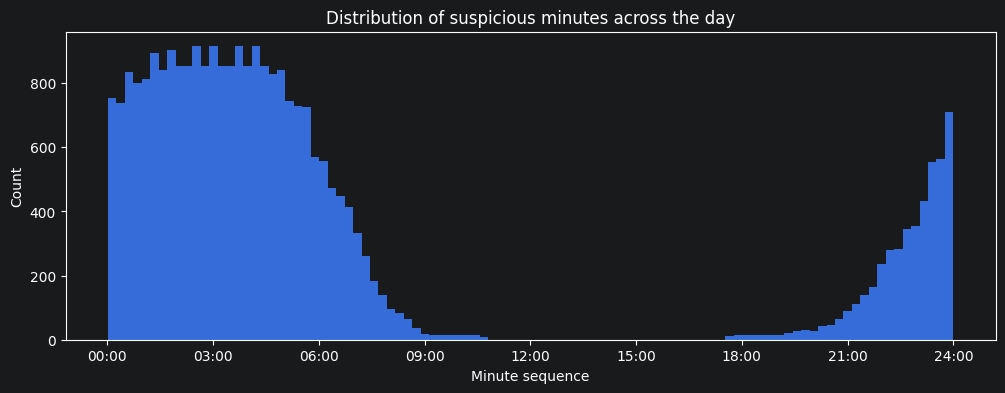

In [44]:
# Explore suspicious minutes distribution across the day

suspicious_minutes = (
    minute_metrics_08[
        minute_metrics_08["is_suspicious"] == True
    ]["minute_sequence"]
)

plt.figure(figsize=(12, 4))
plt.hist(suspicious_minutes, bins=100)
plt.xlabel("Minute sequence")
plt.ylabel("Count")
plt.title("Distribution of suspicious minutes across the day")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [45]:
# count of affected participants

suspicious_participants = minute_metrics_08[minute_metrics_08["is_suspicious"] == True]["ID"].nunique()
total_participants = minute_metrics_08["ID"].nunique()

print(f"Participants with at least one suspicious minute: "
      f"{suspicious_participants} of {total_participants} "
      f"({100 * suspicious_participants / total_participants:.1f}%)")

Participants with at least one suspicious minute: 35 of 1433 (2.4%)


In [46]:
# Drop suspicious minutes from the minute-level dataset to avoid skewing the harmonic regression

suspicious_ids = minute_metrics_08[minute_metrics_08["is_suspicious"] == True]["ID"].unique()
minute_metrics_08 = minute_metrics_08[~minute_metrics_08["ID"].isin(suspicious_ids)]

print(f"Removed {len(suspicious_ids)} participants with suspicious flags.")
print(f"Remaining participants: {minute_metrics_08['ID'].nunique():,}")

Removed 35 participants with suspicious flags.
Remaining participants: 1,398


### 1.2 Explore non_wear minutes distribution across the day and remove fully non-wear days

In [47]:
# Identify fully non-wear days
fully_non_wear_days = (
    minute_metrics_08
    .groupby(["ID", "study_day"])
    .apply(lambda day: (day["is_non_wear"] == True).all())
)

fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]
print(f"Participant-days where entire day is non-wear: {len(fully_non_wear_days)}")
print(f"Participants affected: {fully_non_wear_days.index.get_level_values('ID').nunique()}")


Participant-days where entire day is non-wear: 110
Participants affected: 71


In [48]:
# Drop fully non wear days from the minute-level dataset to avoid skewing the harmonic regression
fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]

minute_metrics_08 = minute_metrics_08[
    ~minute_metrics_08.set_index(["ID", "study_day"]).index.isin(fully_non_wear_days.index)
].reset_index(drop=True)

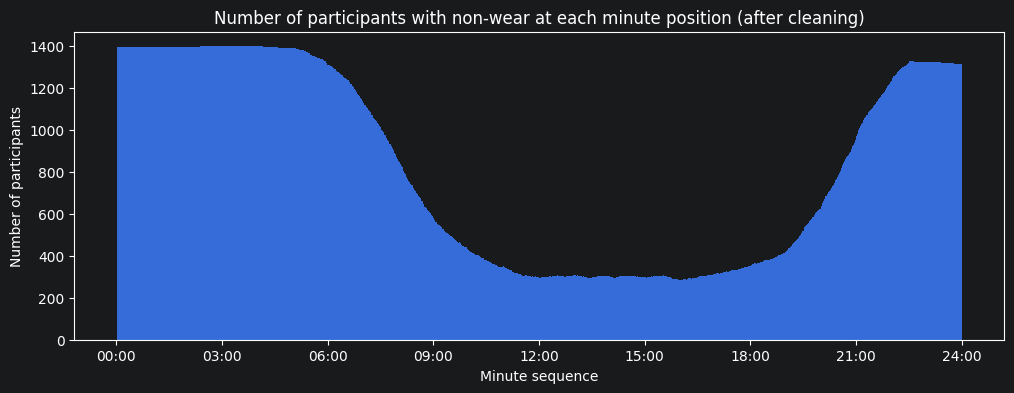

In [49]:
# non wear distribution plot after cleaning
non_wear_per_minute = (
    minute_metrics_08[minute_metrics_08["is_non_wear"] == True]
    .groupby("minute_sequence")["ID"]
    .nunique()
)

plt.figure(figsize=(12, 4))
plt.bar(non_wear_per_minute.index, non_wear_per_minute.values, width=1)
plt.xlabel("Minute sequence")
plt.ylabel("Number of participants")
plt.title("Number of participants with non-wear at each minute position (after cleaning)")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [50]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_08,
    second_dataframe=minute_metrics_08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1391
Only in first: 35
Only in second: 7


### 1.3 Remove days with implausible wear time
Drop days with less than 10 hours of wear and 24 hours of wear time to ensure stable harmonic regression fits

remeber to justify the 10h lower bound and the 24h exclusion

In [51]:
wear_time_per_day = (
    minute_metrics_08
    .groupby(["ID", "study_day"])["is_non_wear"]
    .apply(lambda x: (x == False).sum() / 60)
    .reset_index()
    .rename(columns={"is_non_wear": "wear_hours"})
)

invalid_days = wear_time_per_day[
    (wear_time_per_day["wear_hours"] == 24) |
    (wear_time_per_day["wear_hours"] < 10)
][["ID", "study_day"]]

minute_metrics_08 = minute_metrics_08[
    ~minute_metrics_08.set_index(["ID", "study_day"]).index.isin(
        invalid_days.set_index(["ID", "study_day"]).index
    )
].reset_index(drop=True)

print(f"Dropped {len(invalid_days):,} days.")
print(f"Remaining participants: {minute_metrics_08['ID'].nunique():,}")

Dropped 586 days.
Remaining participants: 1,392


In [52]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_08,
    second_dataframe=minute_metrics_08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1391
Only in first: 35
Only in second: 1


### 1.4 Remove participants with fewer than 4 valid days

remember to justify why a 4-day minimum

In [53]:
days_per_participant = (
    minute_metrics_08
    .groupby("ID")["study_day"]
    .nunique()
)

valid_participants = days_per_participant[days_per_participant >= 4].index

participants_before = minute_metrics_08["ID"].nunique()
minute_metrics_08 = minute_metrics_08[minute_metrics_08["ID"].isin(valid_participants)].reset_index(drop=True)
participants_after = minute_metrics_08["ID"].nunique()

print(f"Dropped {participants_before - participants_after:,} participants with fewer than 4 valid days.")
print(f"Remaining participants: {participants_after:,}")

Dropped 23 participants with fewer than 4 valid days.
Remaining participants: 1,369


### Compare IDs between summary metric and minute metric datasets to check for any discrepancies after cleaning

In [54]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_08,
    second_dataframe=minute_metrics_08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1369
Only in first: 57
Only in second: 0


### Synchronise valid IDs across all dataframes after minute level cleaning

In [55]:
valid_ids_after_cleaning = set(minute_metrics_08["ID"].unique())

daily_metrics_08 = daily_metrics_08[
    daily_metrics_08["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

# summary_metrics_08 uses ID as index at this point in the pipeline
summary_metrics_08 = summary_metrics_08[
    summary_metrics_08["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

print(
    f"Participants after synchronisation:\n"
    f"  minute_metrics_08 : {minute_metrics_08['ID'].nunique():,}\n"
    f"  daily_metrics_08  : {daily_metrics_08['ID'].nunique():,}\n"
    f"  summary_metrics_08: {len(summary_metrics_08):,}"
)

Participants after synchronisation:
  minute_metrics_08 : 1,369
  daily_metrics_08  : 1,369
  summary_metrics_08: 1,005


## Fit harmonic regression model to each participant's minute-level data and extract activity profile features

five features per participant.
Three from harmonic regression (MESOR, amplitude, acrophase) describing
the *shape* of the average daily rhythm. Two nonparametric indices
(IV, IS) describing within-day fragmentation and between-day consistency,
which the harmonic fit cannot capture by construction.

### 2.1 Compute the mean daily activity curve

In [56]:
# gropupby ID, minute_sequence

mean_daily_curve = (
    minute_metrics_08
    .groupby(["ID", "minute_sequence"])["counts"]
    .mean()
    .reset_index()
    .rename(columns={"counts": "mean_counts"})
)

print(f"Mean daily curve computed for {mean_daily_curve['ID'].nunique():,} participants.")
print(mean_daily_curve.head())

Mean daily curve computed for 1,369 participants.
        ID  minute_sequence  mean_counts
0  9000099                1          0.0
1  9000099                2          0.0
2  9000099                3          0.0
3  9000099                4          0.0
4  9000099                5          0.0


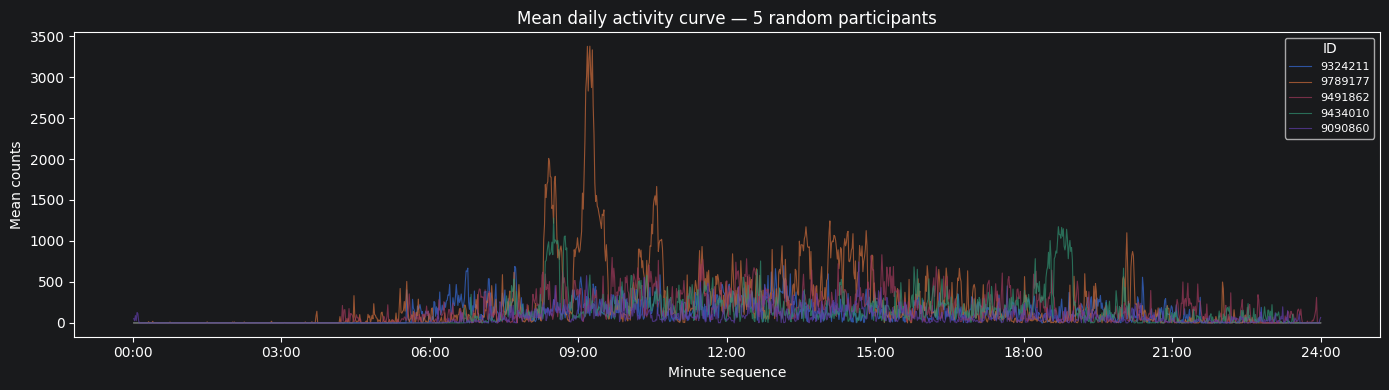

In [57]:
# Plot mean daily curve for a few random participants to verify the shape (sanity check)

sample_ids = mean_daily_curve["ID"].drop_duplicates().sample(5, random_state=42)

fig, ax = plt.subplots(figsize=(14, 4))

for participant_id in sample_ids:
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    ax.plot(
        participant_curve["minute_sequence"],
        participant_curve["mean_counts"],
        alpha=0.7,
        linewidth=0.8,
        label=str(participant_id),
    )

ax.set_xlabel("Minute sequence")
ax.set_ylabel("Mean counts")
ax.set_title("Mean daily activity curve — 5 random participants")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend(title="ID", fontsize=8)
plt.tight_layout()
plt.show()

### 2.2 Harmonic regression with single participant demonstration

intercept (MESOR) plus two harmonic
pairs at periods of 24h and 12h, fitted with ordinary least squares.
Note that acrophase is read from argmax of the fitted curve rather
than from arctan2 of the coefficients to avoid sign-convention bugs.

In [58]:
# manual fit for single participant

participant_id = 9647679

single_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]

minutes = single_curve["minute_sequence"].to_numpy(dtype=float)
counts = single_curve["mean_counts"].to_numpy(dtype=float)

# Build design matrix: intercept + 2 harmonic pairs
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),                                    # MESOR
    np.cos(2 * np.pi * 1 * minutes / period),                # harmonic 1 cosine
    np.sin(2 * np.pi * 1 * minutes / period),                # harmonic 1 sine
    np.cos(2 * np.pi * 2 * minutes / period),                # harmonic 2 cosine
    np.sin(2 * np.pi * 2 * minutes / period),                # harmonic 2 sine
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
# Read acrophase directly from the peak of the fitted curve
# rather than computing from arctan2 to avoid sign convention issues
fitted_counts = design_matrix @ coefficients
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f} hours ({int(peak_minute // 60):02d}:{int(peak_minute % 60):02d})")

MESOR: 249.72
Amplitude: 300.64
Acrophase: 14.92 hours (14:55)


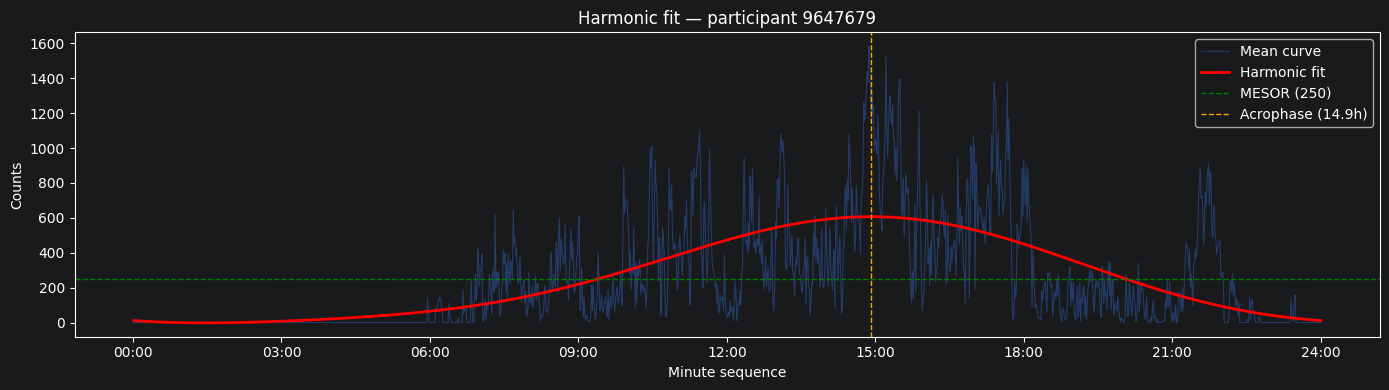

In [59]:
# plot showing curve, fit, MESOR line, acrophase line

fitted_counts = design_matrix @ coefficients

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
ax.axhline(y=mesor, color="green", linestyle="--", linewidth=1, label=f"MESOR ({mesor:.0f})")
ax.axvline(x=acrophase_hours * 60, color="orange", linestyle="--", linewidth=1, label=f"Acrophase ({acrophase_hours:.1f}h)")
ax.set_xlabel("Minute sequence")
ax.set_ylabel("Counts")
ax.set_title(f"Harmonic fit — participant {participant_id}")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend()
plt.tight_layout()
plt.show()


### 2.3 Apply harmonic regression to all participants

In [60]:
# fit_harmonic_model function

def fit_harmonic_model(
        mean_daily_curve: pd.DataFrame,
        column_id: str,
        column_minute_sequence: str,
        column_mean_counts: str,
        period: int = 1440,
        number_of_harmonics: int = 2,
) -> pd.DataFrame:

    # Fit a harmonic regression model to each participant's mean daily curve and extract MESOR, amplitude, and acrophase.

    records = []

    for participant_id, participant_curve in mean_daily_curve.groupby(column_id):
        minutes = participant_curve[column_minute_sequence].to_numpy(dtype=float)
        counts = participant_curve[column_mean_counts].to_numpy(dtype=float)

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)

        fitted_counts = design_matrix @ coefficients
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hour = peak_minute /60

        records.append({
            column_id: participant_id,
            "mesor":mesor,
            "amplitude":amplitude,
            "acrophase":acrophase_hour,
        })

    return pd.DataFrame(records).set_index(column_id)

harmonic_features = fit_harmonic_model(
    mean_daily_curve = mean_daily_curve,
    column_id = "ID",
    column_minute_sequence = "minute_sequence",
    column_mean_counts = "mean_counts",
)

print(f"Harmonic features extracted for {len(harmonic_features)} participants:")
print(harmonic_features.describe())


Harmonic features extracted for 1369 participants:
             mesor    amplitude    acrophase
count  1369.000000  1369.000000  1369.000000
mean    145.345042   152.738024    12.452946
std      76.560058    89.856597     2.943291
min       4.088773     6.276765     1.983333
25%      90.098843    91.622394    10.366667
50%     130.242659   132.440480    12.083333
75%     187.190972   195.003527    14.433333
max     594.441964  1039.607906    22.416667


### 2.4 Explore distribution of acrophase values across participants

describe what an extreme acrophase means (needs to be done) — peak before 6am
    or after 8pm is unusual and worth visual inspection. Document the
    decision: keep

In [61]:
# find participants with acrophase < 6 or > 20

print(harmonic_features[harmonic_features["acrophase"] < 6])
print(harmonic_features[harmonic_features["acrophase"] > 20])

              mesor   amplitude  acrophase
ID                                        
9120358  332.325231  145.517999   4.733333
9148828   52.818056   32.931161   5.316667
9449834  321.236111  390.460594   4.766667
9613942  155.061409  152.585073   5.183333
9652894  244.959921  143.141685   5.966667
9659659  219.621825  147.649717   5.166667
9851758  171.058565  124.240462   1.983333
              mesor   amplitude  acrophase
ID                                        
9632922  204.378075  228.364826  22.416667
9635414  126.618287  106.163791  20.016667
9677734  152.843948  111.442426  20.333333


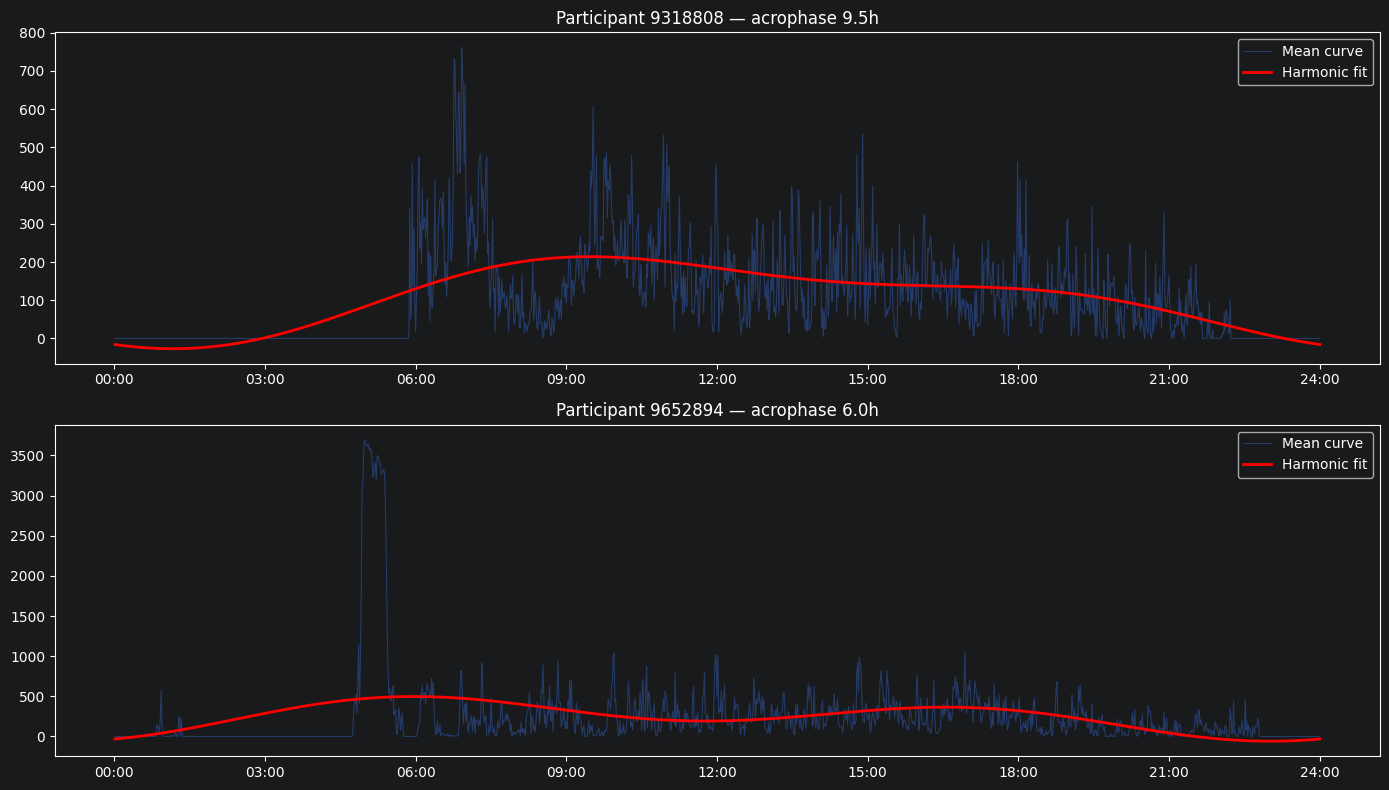

In [62]:
# Plot two outlier examples

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8))

for ax, participant_id in zip(axes, [9318808, 9652894]):
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    minutes = participant_curve["minute_sequence"].to_numpy(dtype=float)
    counts = participant_curve["mean_counts"].to_numpy(dtype=float)

    design_matrix = np.column_stack([
        np.ones(len(minutes)),
        np.cos(2 * np.pi * 1 * minutes / 1440),
        np.sin(2 * np.pi * 1 * minutes / 1440),
        np.cos(2 * np.pi * 2 * minutes / 1440),
        np.sin(2 * np.pi * 2 * minutes / 1440),
    ])
    coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
    fitted_counts = design_matrix @ coefficients

    ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
    ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
    ax.set_title(f"Participant {participant_id} — acrophase {harmonic_features.loc[participant_id, 'acrophase']:.1f}h")
    ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
    ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
    ax.legend()

plt.tight_layout()
plt.show()

### 2.5 Intradaily Variability (IV) and Interdaily Stability (IS)

Harmonic regression describes the *shape* of the daily activity rhythm (when does
the person peak, how active are they on average). IV and IS describe two complementary
dimensions that harmonic parameters cannot capture:

IV: Within-day fragmentation — how much does the person's activity fluctuate up and down across the day?
    - High IV = lots of short bursts of activity interspersed with rest (frequent stop-and-go pattern)
    - Low IV = more consolidated activity and rest periods (smooth, sustained activity pattern)

IS: Day-to-day consistency — how similar is the person's activity pattern across different days?
    - High IS = very regular routine, similar activity levels at the same times each day
    - Low IS = irregular routine, varying activity levels and timing across days

Technical note
IV and IS are computed from the **raw minute-level data across all valid days**,
not from the mean daily curve. This is intentional, both indices specifically
quantify variability over time, which the mean curve averages away by design.

#### IV single participant demonstration

In [63]:
participant_id = 9647679

participant_data = (
    minute_metrics_08[minute_metrics_08["ID"] == participant_id]
    .sort_values(["study_day", "minute_sequence"])
)

counts = participant_data["counts"].to_numpy(dtype=float)

# IV: ratio of mean squared first-order differences to overall variance
# n * sum of squared differences between consecutive minutes
# divided by (n-1) * overall variance
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)

iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"IV for participant {participant_id}: {iv:.4f}")

IV for participant 9647679: 0.3138


#### 2.5.2 IS single participant demonstration

In [64]:
# IS: ratio of variance of the mean 24h profile to overall variance
# Reshape counts into a matrix of days x minutes
number_of_complete_days = len(counts) // 1440
trimmed_counts = counts[:number_of_complete_days * 1440]
reshaped = trimmed_counts.reshape(number_of_complete_days, 1440)

# Mean activity at each of the 1440 minute positions across all days
mean_24h_profile = np.mean(reshaped, axis=0)
overall_mean = np.mean(trimmed_counts)

profile_variance = np.sum((mean_24h_profile - overall_mean) ** 2)
overall_variance = np.sum((trimmed_counts - overall_mean) ** 2)

is_index = (number_of_complete_days * profile_variance) / overall_variance

print(f"IS for participant {participant_id}: {is_index:.4f}")

IS for participant 9647679: 0.2372


#### 2.5.3 Apply IV and IS to all participants

In [65]:
# compute_iv_and_is function
def compute_iv_and_is(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    minutes_per_day: int = 1440,
) -> pd.DataFrame:
    """
    Compute intradaily variability (IV) and interdaily stability (IS)
    for each participant from the raw minute-level activity data.

    IV and IS are computed from the raw multi-day signal rather than
    the mean daily curve because both indices specifically quantify
    variability over time, which the mean curve averages away.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param minutes_per_day: Number of minutes per day (1440).
    :return: DataFrame indexed by participant ID with columns
        [intradaily_variability, interdaily_stability].
    """
    records = []

    for participant_id, participant_data in minute_dataframe.groupby(column_id):
        participant_data = participant_data.sort_values(
            by=[column_study_day, column_minute_sequence]
        )
         # Fill residual NaN values with 0 before computing variance-based indices
        counts = participant_data[column_counts].to_numpy(dtype=float)
        counts = np.nan_to_num(counts, nan=0.0)

        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)

        # IV
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

        # IS
        number_of_complete_days = number_of_minutes // minutes_per_day
        trimmed_counts = counts[:number_of_complete_days * minutes_per_day]
        reshaped = trimmed_counts.reshape(number_of_complete_days, minutes_per_day)
        mean_24h_profile = np.mean(reshaped, axis=0)
        overall_mean_trimmed = np.mean(trimmed_counts)
        profile_variance = np.sum((mean_24h_profile - overall_mean_trimmed) ** 2)
        overall_variance_trimmed = np.sum((trimmed_counts - overall_mean_trimmed) ** 2)
        is_index = (number_of_complete_days * profile_variance) / overall_variance_trimmed

        records.append({
            column_id: participant_id,
            "intradaily_variability": iv,
            "interdaily_stability": is_index,
        })

    return pd.DataFrame(records).set_index(column_id)

# apply function
rhythm_indices = compute_iv_and_is(
    minute_dataframe=minute_metrics_08,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

# describe IV an IS
print(f"IV and IS computed for {len(rhythm_indices)} participants.")
print(rhythm_indices.describe())

IV and IS computed for 1369 participants.
       intradaily_variability  interdaily_stability
count             1369.000000           1369.000000
mean                 0.649199              0.228404
std                  0.248485              0.055280
min                  0.030831              0.119354
25%                  0.460312              0.192528
50%                  0.667152              0.218681
75%                  0.827283              0.250908
max                  1.519772              0.782931


## 3. Merge features into the summary metrics_08

In [66]:
summary_metrics_08 = summary_metrics_08.set_index("ID")

summary_metrics_08 = summary_metrics_08.join(harmonic_features, how="left")
summary_metrics_08 = summary_metrics_08.join(rhythm_indices, how="left")

print(f"Summary data shape after merging: {summary_metrics_08.shape}")
print(f"Missing values for new features:")
print(summary_metrics_08[["mesor", "amplitude", "acrophase",
                           "intradaily_variability", "interdaily_stability"]].isna().sum())

Summary data shape after merging: (1005, 115)
Missing values for new features:
mesor                     0
amplitude                 0
acrophase                 0
intradaily_variability    0
interdaily_stability      0
dtype: int64


## 4. Descriptive exploration of activity profile features

### 4.1 Defining grouping variables
KL grade, employment, weekend, weekday --> needs later more explanation

#### 4.1.1 KL grade severity groups

In [67]:
# Group KL grades into three clinically meaningful severity groups
kl_grade_mapping = {0: "KL 0-1", 1: "KL 0-1", 2: "KL 2-3", 3: "KL 2-3", 4: "KL 4"}

summary_metrics_08 = summary_metrics_08.copy()
summary_metrics_08["kl_grade_group"] = summary_metrics_08["kl_grade_index_knee"].map(kl_grade_mapping)

daily_metrics_08 = daily_metrics_08.copy()
daily_metrics_08["kl_grade_group"] = daily_metrics_08["kl_grade_index_knee"].map(kl_grade_mapping)

print("Summary metrics:")
print(summary_metrics_08["kl_grade_group"].value_counts(dropna=False))
print("\nDaily metrics:")
print(daily_metrics_08["kl_grade_group"].value_counts(dropna=False))

Summary metrics:
kl_grade_group
KL 0-1    527
KL 2-3    440
KL 4       36
NaN         2
Name: count, dtype: int64

Daily metrics:
kl_grade_group
KL 0-1    3529
KL 2-3    2918
NaN       2435
KL 4       242
Name: count, dtype: int64


#### 4.1.2. Employmet status

Group employment into working vs not working
Categories 1 (paid) and 2 (unpaid family) are considered working
Categories 3 (not working due to health) and 4 (not working other) are not working

In [68]:
employment_mapping = {
    1.0: "working",
    2.0: "working",
    3.0: "not working",
    4.0: "not working",
}
summary_metrics_08["employment_group"] = summary_metrics_08["V08CEMPLOY"].map(employment_mapping)
print(summary_metrics_08["employment_group"].value_counts())

employment_group
working        539
not working    448
Name: count, dtype: int64


In [69]:
# merge employment status to daily metrics
daily_metrics_08 = daily_metrics_08.merge(
    summary_metrics_08[["employment_group"]].reset_index(),
    on="ID",
    how="left",
)
print(daily_metrics_08["employment_group"].value_counts())

employment_group
working        3606
not working    2973
Name: count, dtype: int64


#### 4.1.3 Weekday vs weekend day type

In [70]:
# define weekend days and weekday days

weekend_days = ["Saturday", "Sunday"]
daily_metrics_08["day_type"] = daily_metrics_08["week_day"].apply(
    lambda day: "weekend" if day in weekend_days else "weekday"
)

### 4.2. Activity profile features by KL grade

In [71]:
features_of_interest = ["mesor", "amplitude", "acrophase",
                         "intradaily_variability", "interdaily_stability"]

kl_grade_descriptives = (
    summary_metrics_08
    .groupby("kl_grade_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

                  mesor                  amplitude                  acrophase  \
                   mean     std   median      mean     std   median      mean   
kl_grade_group                                                                  
KL 0-1          154.885  81.930  139.155   161.669  93.591  139.666    12.477   
KL 2-3          149.103  75.837  136.206   158.546  96.182  140.628    12.647   
KL 4            125.008  70.791  105.253   127.338  70.901  116.876    12.008   

                              intradaily_variability                \
                  std  median                   mean    std median   
kl_grade_group                                                       
KL 0-1          3.019  12.117                  0.618  0.243  0.635   
KL 2-3          3.048  12.108                  0.631  0.253  0.659   
KL 4            2.372  11.742                  0.714  0.212  0.700   

               interdaily_stability                
                               mean    s

### 4.3 Activity profile features by employment status

activity profile features by day type -> not possible with one curve per participant, try with day to day curve --> maybe add later to explore the differences

In [72]:
employment_status_descriptives = (
    summary_metrics_08
    .groupby("employment_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_status_descriptives)

                    mesor                  amplitude                   \
                     mean     std   median      mean     std   median   
employment_group                                                        
not working       128.221  72.637  109.751   145.321  98.214  122.508   
working           170.172  78.786  154.642   170.694  89.387  151.701   

                 acrophase                intradaily_variability         \
                      mean    std  median                   mean    std   
employment_group                                                          
not working         12.014  2.579  11.625                  0.654  0.262   
working             12.984  3.263  12.617                  0.603  0.230   

                        interdaily_stability                
                 median                 mean    std median  
employment_group                                            
not working       0.672                0.233  0.058  0.222  
working       

## 5. Per-day harmonic decomposition

description why change to per day harmonic

### 5.1 Single-day demonstration for on participant

In [73]:
participant_id = 9000099
study_day = 1080

single_day = (
    minute_metrics_08[
        (minute_metrics_08["ID"] == participant_id) &
        (minute_metrics_08["study_day"] == study_day)
    ]
    .sort_values("minute_sequence")
)

minutes = single_day["minute_sequence"].to_numpy(dtype=float)
counts = single_day["counts"].to_numpy(dtype=float)
counts = np.nan_to_num(counts, nan=0.0)

# Harmonic model
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),
    np.cos(2 * np.pi * 1 * minutes / period),
    np.sin(2 * np.pi * 1 * minutes / period),
    np.cos(2 * np.pi * 2 * minutes / period),
    np.sin(2 * np.pi * 2 * minutes / period),
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
fitted_counts = design_matrix @ coefficients

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

# IV
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)
iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f}h")
print(f"IV: {iv:.4f}")

MESOR: 333.24
Amplitude: 367.84
Acrophase: 7.87h
IV: 0.1637


### 5.2 Per-day function across all participant-days

same harmonic specification as section 2, but fitted to each participant-day independently rather than to the mean curve

In [74]:
# harmonic regression features and iv function

def extract_daily_harmonic_and_iv(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression and compute intradaily variability (IV)
    for each participant-day.

    Unlike the participant-level harmonic features which are fitted to the
    mean daily curve, these features are computed per individual day to enable
    weekday vs weekend and employment status comparisons.

    IS is excluded here as it requires multiple days by definition and
    remains a participant-level feature only.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param period: Period in minutes (1440 for daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant-day containing
        mesor, amplitude, acrophase, and intradaily_variability.
    """
    records = []

    for (participant_id, study_day), day_data in minute_dataframe.groupby(
        [column_id, column_study_day]
    ):
        day_data = day_data.sort_values(column_minute_sequence)
        minutes = day_data[column_minute_sequence].to_numpy(dtype=float)
        counts = np.nan_to_num(
            day_data[column_counts].to_numpy(dtype=float), nan=0.0
        )

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        # IV
        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (
            (number_of_minutes * squared_differences)
            / ((number_of_minutes - 1) * overall_variance)
            if overall_variance > 0 else np.nan
        )

        records.append({
            column_id: participant_id,
            column_study_day: study_day,
            "mesor_daily": mesor,
            "amplitude_daily": amplitude,
            "acrophase_daily": acrophase_hours,
            "intradaily_variability_daily": iv,
        })

    return pd.DataFrame(records)


# apply function
daily_harmonic_features = extract_daily_harmonic_and_iv(
    minute_dataframe=minute_metrics_08,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

print(f"Daily harmonic features extracted for {len(daily_harmonic_features)} participant-days.")
print(daily_harmonic_features.describe())

Daily harmonic features extracted for 9341 participant-days.
                 ID    study_day  mesor_daily  amplitude_daily  \
count  9.341000e+03  9341.000000  9341.000000      9341.000000   
mean   9.504304e+06  1036.607323   145.356218       166.365823   
std    2.863207e+05   131.744387    94.548024       129.331918   
min    9.000099e+06   781.000000     2.102083         3.555058   
25%    9.260515e+06   946.000000    78.735417        80.284539   
50%    9.504363e+06  1031.000000   121.984722       130.136908   
75%    9.743839e+06  1143.000000   186.708333       213.321114   
max    9.999878e+06  1427.000000   812.075694      1230.221998   

       acrophase_daily  intradaily_variability_daily  
count      9341.000000                   9341.000000  
mean         12.714104                      0.743394  
std           3.456863                      0.300916  
min           0.366667                      0.015880  
25%          10.083333                      0.537956  
50%          1

#### 5.2.1. Merge features to daily_metrics_08 and save as CSV

In [75]:
# merge daily harmonic features to daily_metrics_08

daily_metrics_08 = daily_metrics_08.merge(
    daily_harmonic_features[
        [
            "ID",
            "study_day",
            "mesor_daily",
            "amplitude_daily",
            "acrophase_daily",
            "intradaily_variability_daily",
        ]
    ],
    on=["ID", "study_day"],
    how="left",
)

daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

#### 5.2.2 Aggregate main curve for weekends and weekdays

In [76]:
# function to extract main curve for weekends and weekdays
def extract_mean_curve_harmonic_by_day_type(
    minute_dataframe: pd.DataFrame,
    daily_metadata_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_of_day: str,
    column_counts: str,
    column_day_type: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression to the participant-level mean daily activity
    curve, separately for weekday and weekend days.

    For each participant and each day type, minute-level activity counts
    are averaged across days at every minute-of-day, producing a single
    24-hour mean curve. A harmonic regression is then fitted to that mean
    curve to derive mesor, amplitude, and acrophase.

    :param minute_dataframe: Cleaned minute-level DataFrame containing
        activity counts.
    :param daily_metadata_dataframe: Daily-level DataFrame containing the
        day type label (weekday / weekend) for each participant-day.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_of_day: Minute-of-day column (0 to 1439).
    :param column_counts: Activity counts column.
    :param column_day_type: Column labelling each day as weekday or weekend.
    :param period: Period in minutes (1440 for a daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant containing mesor,
        amplitude, and acrophase for both weekday and weekend mean curves.
    """
    minute_with_day_type = minute_dataframe.merge(
        daily_metadata_dataframe[[column_id, column_study_day, column_day_type]].drop_duplicates(),
        on=[column_id, column_study_day],
        how="left",
    )

    records = []

    for (participant_id, day_type), participant_day_type_data in minute_with_day_type.groupby(
        [column_id, column_day_type]
    ):
        mean_curve = (
            participant_day_type_data
            .groupby(column_minute_of_day)[column_counts]
            .mean()
            .sort_index()
        )

        minutes = mean_curve.index.to_numpy(dtype=float)
        counts = np.nan_to_num(mean_curve.to_numpy(dtype=float), nan=0.0)

        design_matrix_columns = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix_columns.append(
                np.cos(2 * np.pi * harmonic_index * minutes / period)
            )
            design_matrix_columns.append(
                np.sin(2 * np.pi * harmonic_index * minutes / period)
            )
        design_matrix = np.column_stack(design_matrix_columns)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1] ** 2 + coefficients[2] ** 2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        records.append(
            {
                column_id: participant_id,
                column_day_type: day_type,
                "mesor_mean_curve": mesor,
                "amplitude_mean_curve": amplitude,
                "acrophase_mean_curve": acrophase_hours,
            }
        )

    long_format = pd.DataFrame(records)

    wide_format = long_format.pivot(
        index=column_id,
        columns=column_day_type,
        values=["mesor_mean_curve", "amplitude_mean_curve", "acrophase_mean_curve"],
    )
    wide_format.columns = [
        f"{feature_name}_{day_type_label}"
        for feature_name, day_type_label in wide_format.columns
    ]
    wide_format = wide_format.reset_index()

    return wide_format

In [77]:
# merge curves into summery metrics
mean_curve_features_by_day_type = extract_mean_curve_harmonic_by_day_type(
    minute_dataframe=minute_metrics_08,
    daily_metadata_dataframe=daily_metrics_08,
    column_id="ID",
    column_study_day="study_day",
    column_minute_of_day="minute_sequence",   # adjust if your column is named differently
    column_counts="counts",
    column_day_type="day_type",
)

summary_metrics_08 = summary_metrics_08.merge(
    mean_curve_features_by_day_type,
    on="ID",
    how="left",
)

#### 5.2.4 Filter IV by daytype

In [78]:
iv_by_daytype = (
    daily_metrics_08.assign(
        day_type=lambda dataframe : dataframe["week_day"].
        isin(weekend_days).
        map({True: "weekend", False: "weekday"})
    )
    .groupby(["ID", "day_type"]) ["intradaily_variability_daily"]
    .mean().unstack("day_type")
   .rename(columns={
        "weekday": "iv_weekday",
        "weekend": "iv_weekend",
    })
             )

iv_by_daytype["iv_contrast"] = (
    iv_by_daytype["iv_weekday"] - iv_by_daytype["iv_weekend"]
)

# Merge into the main summary feature dataframe
summary_metrics_08 = summary_metrics_08.merge(
    iv_by_daytype.reset_index(),
    on="ID",
    how="left",
)

In [79]:
# save to csv
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)

### 5.3 Descriptive comparison

#### 5.3.1 By day type (weekday vs weekend)

In [80]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

day_type_descriptives = (
    daily_metrics_08
    .groupby("day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(day_type_descriptives)

         mesor_daily                  amplitude_daily                    \
                mean     std   median            mean      std   median   
day_type                                                                  
weekday      148.106  93.052  125.631         166.122  126.478  131.140   
weekend      144.577  98.374  117.890         173.597  137.415  133.218   

         acrophase_daily                intradaily_variability_daily         \
                    mean    std  median                         mean    std   
day_type                                                                      
weekday           12.735  3.548  12.267                        0.742  0.298   
weekend           12.637  3.189  12.233                        0.732  0.302   

                 
         median  
day_type         
weekday   0.780  
weekend   0.763  


 #### 5.3.2 By employment status

In [81]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

employment_type_descriptives = (
    daily_metrics_08
    .groupby("employment_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_type_descriptives)

                 mesor_daily                   amplitude_daily           \
                        mean      std   median            mean      std   
employment_group                                                          
not working          130.160   87.770  107.464         157.438  129.321   
working              171.418  101.516  145.461         190.418  139.254   

                          acrophase_daily                 \
                   median            mean    std  median   
employment_group                                           
not working       121.445          12.406  3.176  11.933   
working           150.437          13.023  3.671  12.708   

                 intradaily_variability_daily                
                                         mean    std median  
employment_group                                             
not working                             0.750  0.317  0.799  
working                                 0.698  0.287  0.738  


#### 5.3.3 By KL grade

In [82]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

kl_grade_descriptives = (
    daily_metrics_08
    .groupby("kl_grade_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

               mesor_daily                   amplitude_daily           \
                      mean      std   median            mean      std   
kl_grade_group                                                          
KL 0-1             156.670  102.277  130.797         178.842  140.100   
KL 2-3             150.563   93.553  128.533         174.361  132.562   
KL 4               126.508   79.961  106.801         139.120  100.442   

                        acrophase_daily                 \
                 median            mean    std  median   
kl_grade_group                                           
KL 0-1          137.804          12.749  3.472  12.333   
KL 2-3          139.881          12.712  3.487  12.300   
KL 4            107.984          13.057  3.294  12.550   

               intradaily_variability_daily                
                                       mean    std median  
kl_grade_group                                             
KL 0-1                          

#### 5.3.4 By KL grade × day type

In [83]:
daily_metrics_08["kl_day_type"] = (
    daily_metrics_08["kl_grade_group"]
    + " - "
    + daily_metrics_08["day_type"]
)

kl_day_type_descriptives = (
    daily_metrics_08
    .groupby("kl_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_day_type_descriptives)

                 mesor_daily                   amplitude_daily           \
                        mean      std   median            mean      std   
kl_day_type                                                               
KL 0-1 - weekday     156.319   98.599  132.903         174.684  133.890   
KL 0-1 - weekend     157.590  111.407  124.846         189.760  154.773   
KL 2-3 - weekday     153.061   94.286  130.132         174.200  132.877   
KL 2-3 - weekend     144.015   91.338  125.240         174.780  131.814   
KL 4 - weekday       126.261   79.544  106.695         135.848   93.817   
KL 4 - weekend       127.113   81.547  107.793         147.113  115.388   

                          acrophase_daily                 \
                   median            mean    std  median   
kl_day_type                                                
KL 0-1 - weekday  136.251          12.792  3.570  12.333   
KL 0-1 - weekend  141.855          12.637  3.198  12.283   
KL 2-3 - weekday  139.07

#### 5.3.5 By KL grade × employment

In [84]:
daily_metrics_08["kl_employment"] = (
    daily_metrics_08["kl_grade_group"]
    + " - "
    + daily_metrics_08["employment_group"]
)

kl_employment_descriptives = (
    daily_metrics_08
    .groupby("kl_employment")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_descriptives)

                     mesor_daily                   amplitude_daily           \
                            mean      std   median            mean      std   
kl_employment                                                                 
KL 0-1 - not working     134.159   89.549  109.517         162.724  128.214   
KL 0-1 - working         172.976  107.336  144.609         190.943  147.398   
KL 2-3 - not working     128.380   88.811  107.199         155.162  135.010   
KL 2-3 - working         169.128   93.502  146.143         190.293  128.884   
KL 4 - not working       108.922   56.047   96.119         127.703   84.252   
KL 4 - working           180.185  108.197  152.510         177.461  130.054   

                              acrophase_daily                 \
                       median            mean    std  median   
kl_employment                                                  
KL 0-1 - not working  126.518          12.303  3.151  11.867   
KL 0-1 - working      147.152   

#### 5.3.6 By KL grade × employment × day type

In [85]:
daily_metrics_08["kl_employment_day_type"] = (
    daily_metrics_08["kl_grade_group"]
    + " - "
    + daily_metrics_08["employment_group"]
    + " - "
    + daily_metrics_08["day_type"]
)

kl_employment_day_type_descriptives = (
    daily_metrics_08
    .groupby("kl_employment_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_day_type_descriptives)

                               mesor_daily                   amplitude_daily  \
                                      mean      std   median            mean   
kl_employment_day_type                                                         
KL 0-1 - not working - weekday     137.362   90.852  112.929         167.222   
KL 0-1 - not working - weekend     125.775   85.585  101.596         150.953   
KL 0-1 - working - weekday         170.345  101.914  145.681         180.836   
KL 0-1 - working - weekend         179.904  120.278  143.186         217.551   
KL 2-3 - not working - weekday     132.625   93.347  107.590         159.398   
KL 2-3 - not working - weekend     117.591   75.124  104.151         144.397   
KL 2-3 - working - weekday         169.930   91.802  146.595         186.188   
KL 2-3 - working - weekend         166.973   98.001  144.011         201.323   
KL 4 - not working - weekday       109.466   58.147   94.878         129.391   
KL 4 - not working - weekend       107.5

### 5.4 Non-paramatric group comparison (exploratory)

The Kruskal-Wallis test and Dunn post-hoc are applied here as an
exploratory descriptive tool to identify candidate group differences
in the per-day features.

**Important caveat.** These tests assume independent observations, which
is violated in the per-day table because each participant contributes
multiple days (typically 5–7). Within-participant correlation will
deflate the p-values, making them optimistically small. The results
below should therefore be read as a ranking of where group differences
are likely to exist, not as confirmatory inference.

The linear mixed models in section 5.7 address the dependence structure
explicitly by including participant ID as a random intercept, and serve
as the inferential anchor for any conclusions drawn about KL grade,
employment, or day type effects.

In [86]:
def run_kruskal_dunn(
    dataframe: pd.DataFrame,
    feature_columns: list[str],
    group_column: str,
) -> pd.DataFrame:
    """
    Run Kruskal-Wallis test and Dunn post-hoc for each feature across groups.

    Bonferroni correction is applied to the Dunn post-hoc p-values to
    account for multiple comparisons.

    :param dataframe: DataFrame containing features and group column.
    :param feature_columns: List of feature column names to test.
    :param group_column: Column name defining the groups.
    :return: DataFrame with Kruskal-Wallis statistic, p-value, and Dunn
        post-hoc p-values for each feature.
    """
    results = []

    for feature in feature_columns:
        subset = dataframe[[feature, group_column]].dropna()
        groups = [
            group_data[feature].values
            for _, group_data in subset.groupby(group_column)
        ]

        kruskal_statistic, kruskal_pvalue = kruskal(*groups)

        dunn_results = sp.posthoc_dunn(
            subset,
            val_col=feature,
            group_col=group_column,
            p_adjust="bonferroni",
        )

        results.append({
            "feature": feature,
            "kruskal_statistic": round(kruskal_statistic, 3),
            "kruskal_pvalue": round(kruskal_pvalue, 4),
            "dunn_pvalues": dunn_results,
        })

    return results


# Run for all three comparisons
kl_grade_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="kl_grade_group",
)

day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="day_type",
)

employment_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="employment_group",
)

In [87]:
# Print KL grade results
print("KL grade comparisons:")
for result in kl_grade_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nDay type comparisons:")
for result in day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nEmployment comparisons:")
for result in employment_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

KL grade comparisons:

mesor_daily:
  Kruskal-Wallis: H=25.759, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1  1.0000  0.3639   0.0
KL 2-3  0.3639  1.0000   0.0
KL 4    0.0000  0.0000   1.0

amplitude_daily:
  Kruskal-Wallis: H=22.898, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     1.0   0.0
KL 2-3     1.0     1.0   0.0
KL 4       0.0     0.0   1.0

acrophase_daily:
  Kruskal-Wallis: H=2.039, p=0.3607
  Dunn post-hoc:
        KL 0-1  KL 2-3    KL 4
KL 0-1  1.0000  1.0000  0.6507
KL 2-3  1.0000  1.0000  0.4737
KL 4    0.6507  0.4737  1.0000

intradaily_variability_daily:
  Kruskal-Wallis: H=10.932, p=0.0042
  Dunn post-hoc:
        KL 0-1  KL 2-3    KL 4
KL 0-1  1.0000  1.0000  0.0029
KL 2-3  1.0000  1.0000  0.0049
KL 4    0.0029  0.0049  1.0000

Day type comparisons:

mesor_daily:
  Kruskal-Wallis: H=10.25, p=0.0014
  Dunn post-hoc:
         weekday  weekend
weekday   1.0000   0.0014
weekend   0.0014   1.0000

amplitude_daily:
  Kruskal-Wallis: H=1.

In [88]:
kl_employment_day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="kl_employment_day_type",
)

for result in kl_employment_day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")


mesor_daily:
  Kruskal-Wallis: H=428.537, p=0.0
  Dunn post-hoc:
                                KL 0-1 - not working - weekday  \
KL 0-1 - not working - weekday                          1.0000   
KL 0-1 - not working - weekend                          1.0000   
KL 0-1 - working - weekday                              0.0000   
KL 0-1 - working - weekend                              0.0000   
KL 2-3 - not working - weekday                          1.0000   
KL 2-3 - not working - weekend                          0.0560   
KL 2-3 - working - weekday                              0.0000   
KL 2-3 - working - weekend                              0.0000   
KL 4 - not working - weekday                            0.1803   
KL 4 - not working - weekend                            1.0000   
KL 4 - working - weekday                                0.1932   
KL 4 - working - weekend                                1.0000   

                                KL 0-1 - not working - weekend  \
KL 0-1 - 

In [89]:
# summarise dunn results
def summarise_dunn_results(
    test_results: list[dict],
    significance_threshold: float = 0.05,
) -> pd.DataFrame:
    """
    Extract only significant pairwise comparisons from Dunn post-hoc results.

    :param test_results: Output from run_kruskal_dunn.
    :param significance_threshold: P-value threshold for significance.
    :return: Tidy DataFrame with one row per significant pairwise comparison.
    """
    rows = []
    for result in test_results:
        feature = result["feature"]
        kruskal_statistic = result["kruskal_statistic"]
        kruskal_pvalue = result["kruskal_pvalue"]
        dunn = result["dunn_pvalues"]

        groups = dunn.columns.tolist()
        for i, group_a in enumerate(groups):
            for group_b in groups[i + 1:]:
                pvalue = dunn.loc[group_a, group_b]
                if pvalue < significance_threshold:
                    rows.append({
                        "feature": feature,
                        "kruskal_H": kruskal_statistic,
                        "kruskal_p": kruskal_pvalue,
                        "group_a": group_a,
                        "group_b": group_b,
                        "dunn_p": round(pvalue, 4),
                    })

    return pd.DataFrame(rows)


combined_significant = summarise_dunn_results(
    test_results=kl_employment_day_type_tests,
    significance_threshold=0.05,
)

print(f"Total significant pairwise comparisons: {len(combined_significant)}")
print(combined_significant.to_string())


Total significant pairwise comparisons: 73
                         feature  kruskal_H  kruskal_p                         group_a                         group_b  dunn_p
0                    mesor_daily    428.537        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekday  0.0000
1                    mesor_daily    428.537        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekend  0.0000
2                    mesor_daily    428.537        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekday  0.0000
3                    mesor_daily    428.537        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekend  0.0000
4                    mesor_daily    428.537        0.0  KL 0-1 - not working - weekend      KL 0-1 - working - weekday  0.0000
5                    mesor_daily    428.537        0.0  KL 0-1 - not working - weekend      KL 0-1 - working - weekend  0.0000
6                    mesor_daily    428.537        0.0  KL 0-1 - not

### 5.5 Linear mixed models

the Kruskal-Wallis tests above treat each
    participant-day as an independent observation, which is incorrect
    because each participant contributes multiple days. The mixed model
    addresses this by including participant ID as a random intercept,
    so within-participant correlation is properly accounted for. Fixed
    effects: KL grade group, employment group, day type, and the
    KL × employment interaction

In [90]:
# define run_linear_mixed_model function
def run_linear_mixed_model(
    dataframe: pd.DataFrame,
    outcome: str,
    fixed_effects: str,
    group_column: str,
) -> None:
    """
    Fit a linear mixed model with participant as random effect.

    :param dataframe: DataFrame containing outcome, predictors and group.
    :param outcome: Outcome column name.
    :param fixed_effects: Formula string for fixed effects.
    :param group_column: Column defining the random effect grouping (participant ID).
    """
    subset = dataframe[[outcome, "kl_grade_group", "employment_group",
                         "day_type", group_column]].dropna()

    # Encode categorical variables
    subset["kl_grade_group"] = pd.Categorical(
        subset["kl_grade_group"],
        categories=["KL 0-1", "KL 2-3", "KL 4"],
        ordered=True,
    )

    formula = f"{outcome} ~ {fixed_effects}"
    model = smf.mixedlm(
        formula=formula,
        data=subset,
        groups=subset[group_column],
    )
    fitted_model = model.fit(method="bfgs")
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome}")
    print(f"{'='*60}")
    print(fitted_model.summary())


for outcome in features_of_interest_daily:
    run_linear_mixed_model(
        dataframe=daily_metrics_08,
        outcome=outcome,
        fixed_effects="kl_grade_group + employment_group + day_type + kl_grade_group:employment_group",
        group_column="ID",
    )


Outcome: mesor_daily
                               Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               mesor_daily
No. Observations:               6553                  Method:                           REML       
No. Groups:                     985                   Scale:                            3998.0988  
Min. group size:                2                     Log-Likelihood:                   -37560.2309
Max. group size:                7                     Converged:                        Yes        
Mean group size:                6.7                                                                
---------------------------------------------------------------------------------------------------
                                                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------------------
Intercept

### 5.6 Visualisations

In [91]:
# Plot configuration for per-day feature visualisations

# Ordered KL severity groups for consistent plotting across all charts
kl_order = ["KL 0-1", "KL 2-3", "KL 4"]

# Human-readable axis labels for each per-day feature
feature_labels = {
    "mesor_daily": "MESOR (rhythm-adjusted mean activity)",
    "amplitude_daily": "Amplitude (peak-to-trough range)",
    "acrophase_daily": "Acrophase (clock hour of peak)",
    "intradaily_variability_daily": "Intradaily variability (IV)",
}

# Y-axis limits per feature, set to the 1st and 99th percentiles to clip
# extreme outliers and keep the violin shapes visually comparable across groups.
y_limits = {
    feature: (
        daily_metrics_08[feature].quantile(0.01),
        daily_metrics_08[feature].quantile(0.99),
    )
    for feature in feature_labels
}

#### 5.6.1 Violin plots — feature distributions by KL × employment

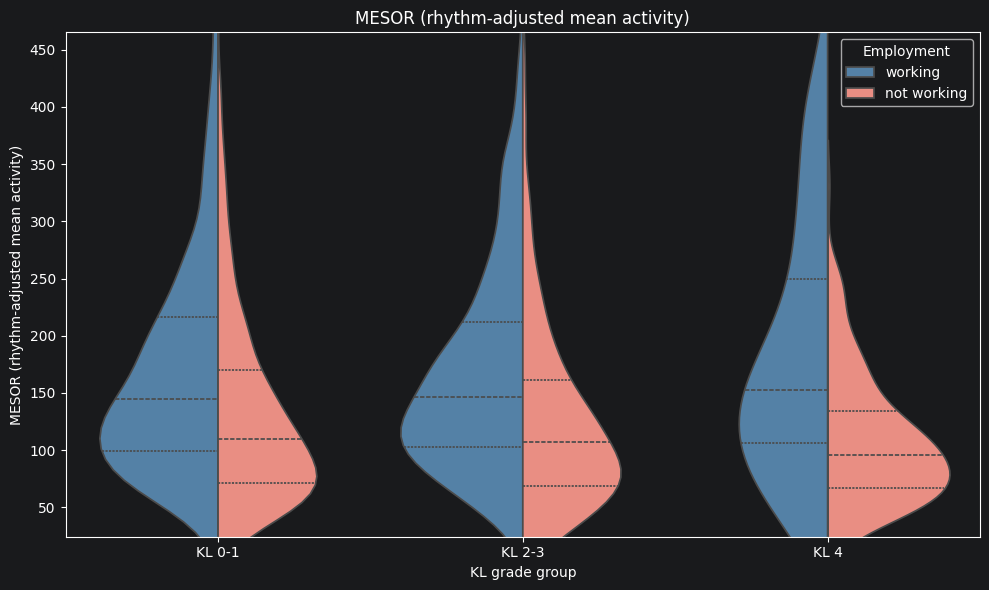

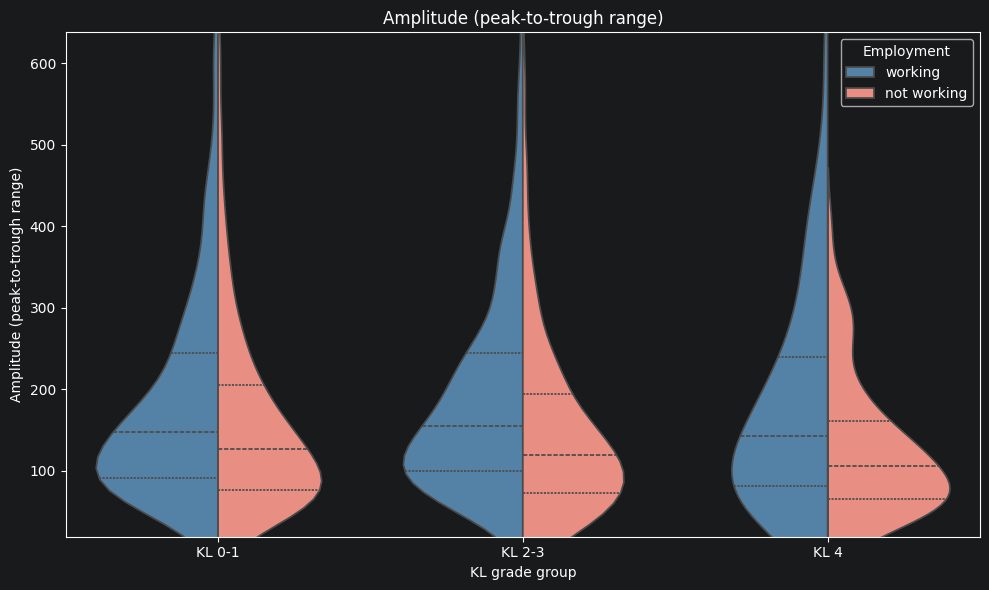

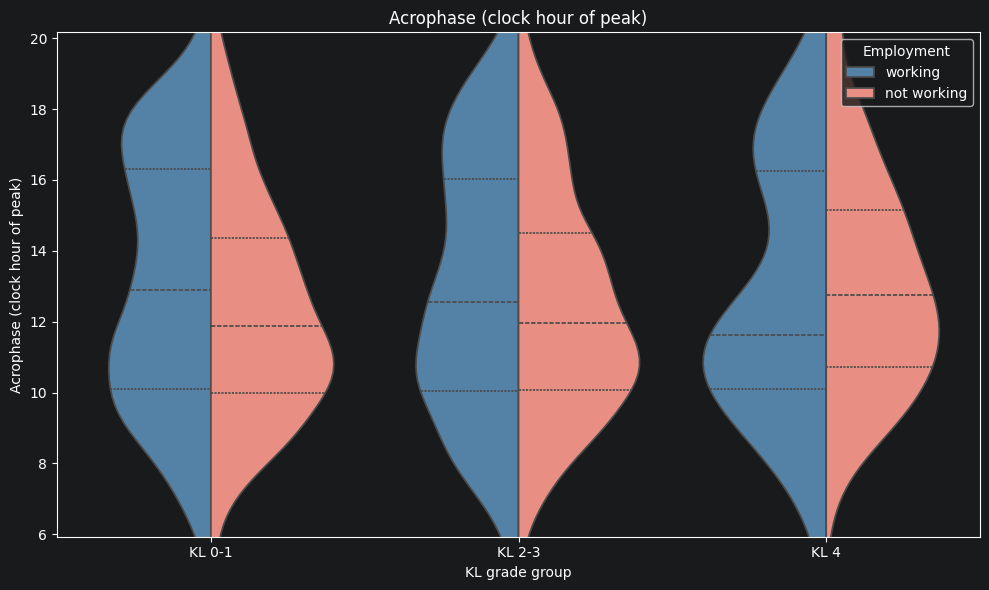

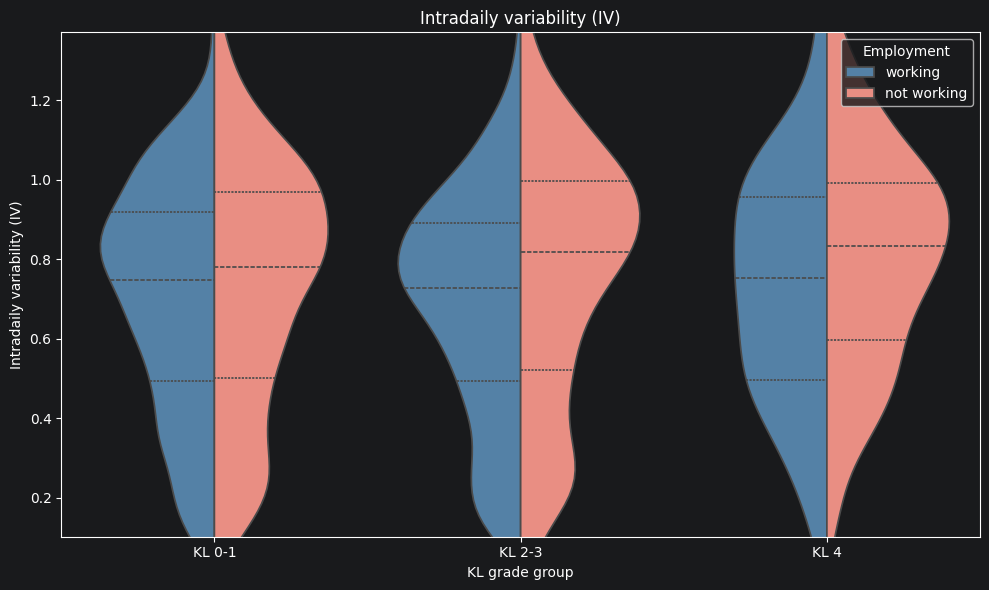

In [92]:
for feature in features_of_interest_daily:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=daily_metrics_08.dropna(subset=[feature]),
        x="kl_grade_group",
        y=feature,
        hue="employment_group",
        order=kl_order,
        hue_order=["working", "not working"],
        split=True,
        inner="quartile",
        palette={"working": "steelblue", "not working": "salmon"},
        ax=ax,
    )
    ax.set_xlabel("KL grade group")
    ax.set_ylabel(feature_labels[feature])
    ax.set_title(feature_labels[feature])
    ax.set_ylim(y_limits[feature])
    ax.legend(title="Employment", loc="upper right")

    plt.tight_layout()
    plt.show()

#### 5.6.2 Interaction plots — KL trajectories split by context

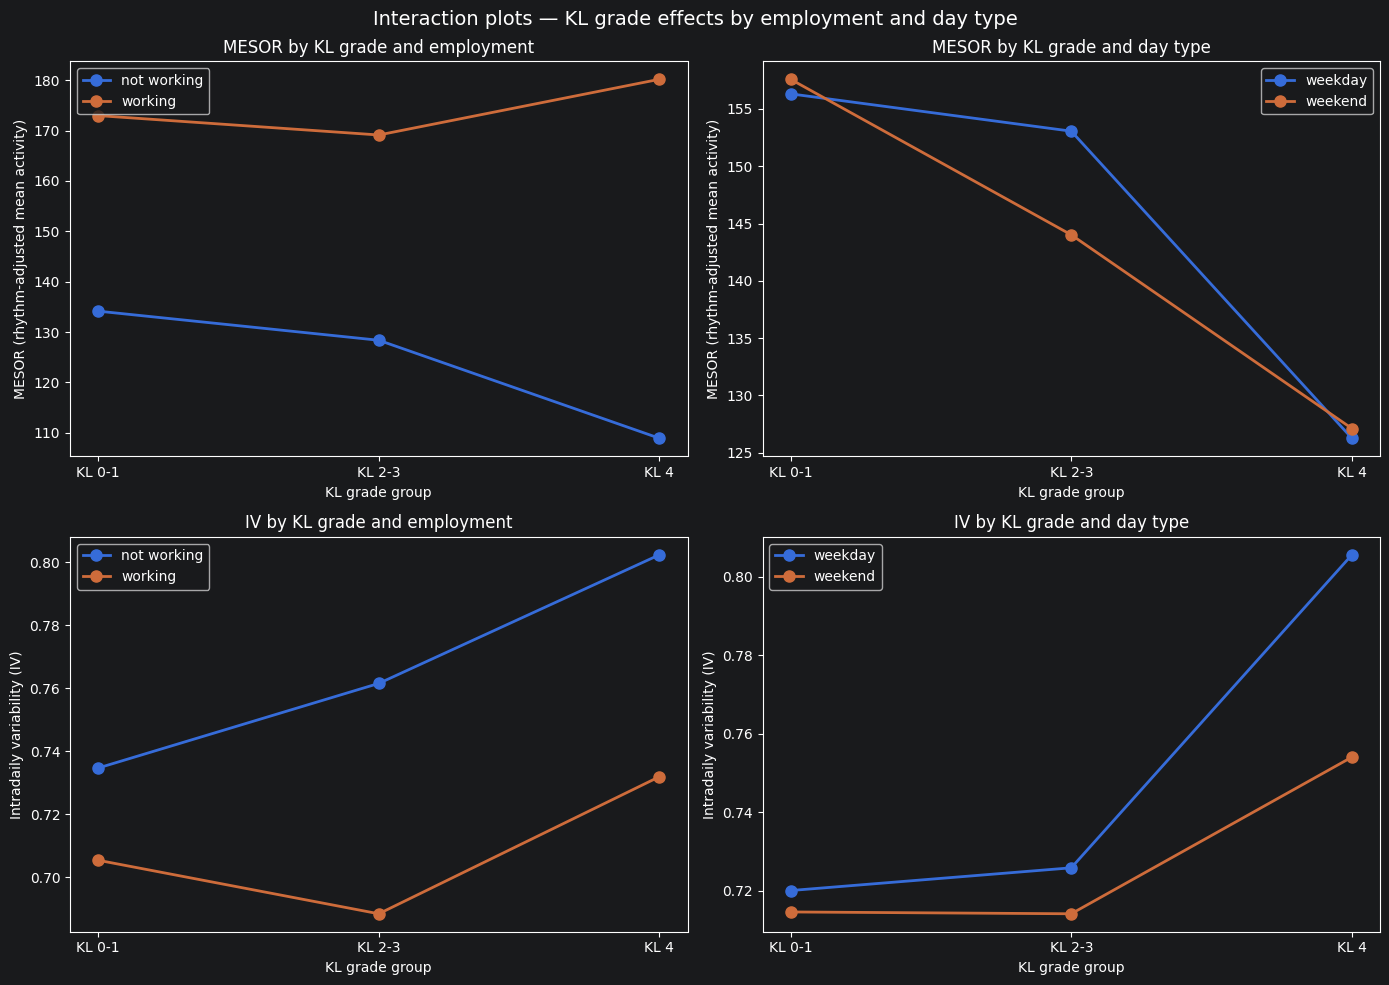

In [93]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

plot_specifications = [
    {"feature": "mesor_daily", "group": "employment_group", "title": "MESOR by KL grade and employment"},
    {"feature": "mesor_daily", "group": "day_type", "title": "MESOR by KL grade and day type"},
    {"feature": "intradaily_variability_daily", "group": "employment_group", "title": "IV by KL grade and employment"},
    {"feature": "intradaily_variability_daily", "group": "day_type", "title": "IV by KL grade and day type"},
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    plot_data = (
        daily_metrics_08
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

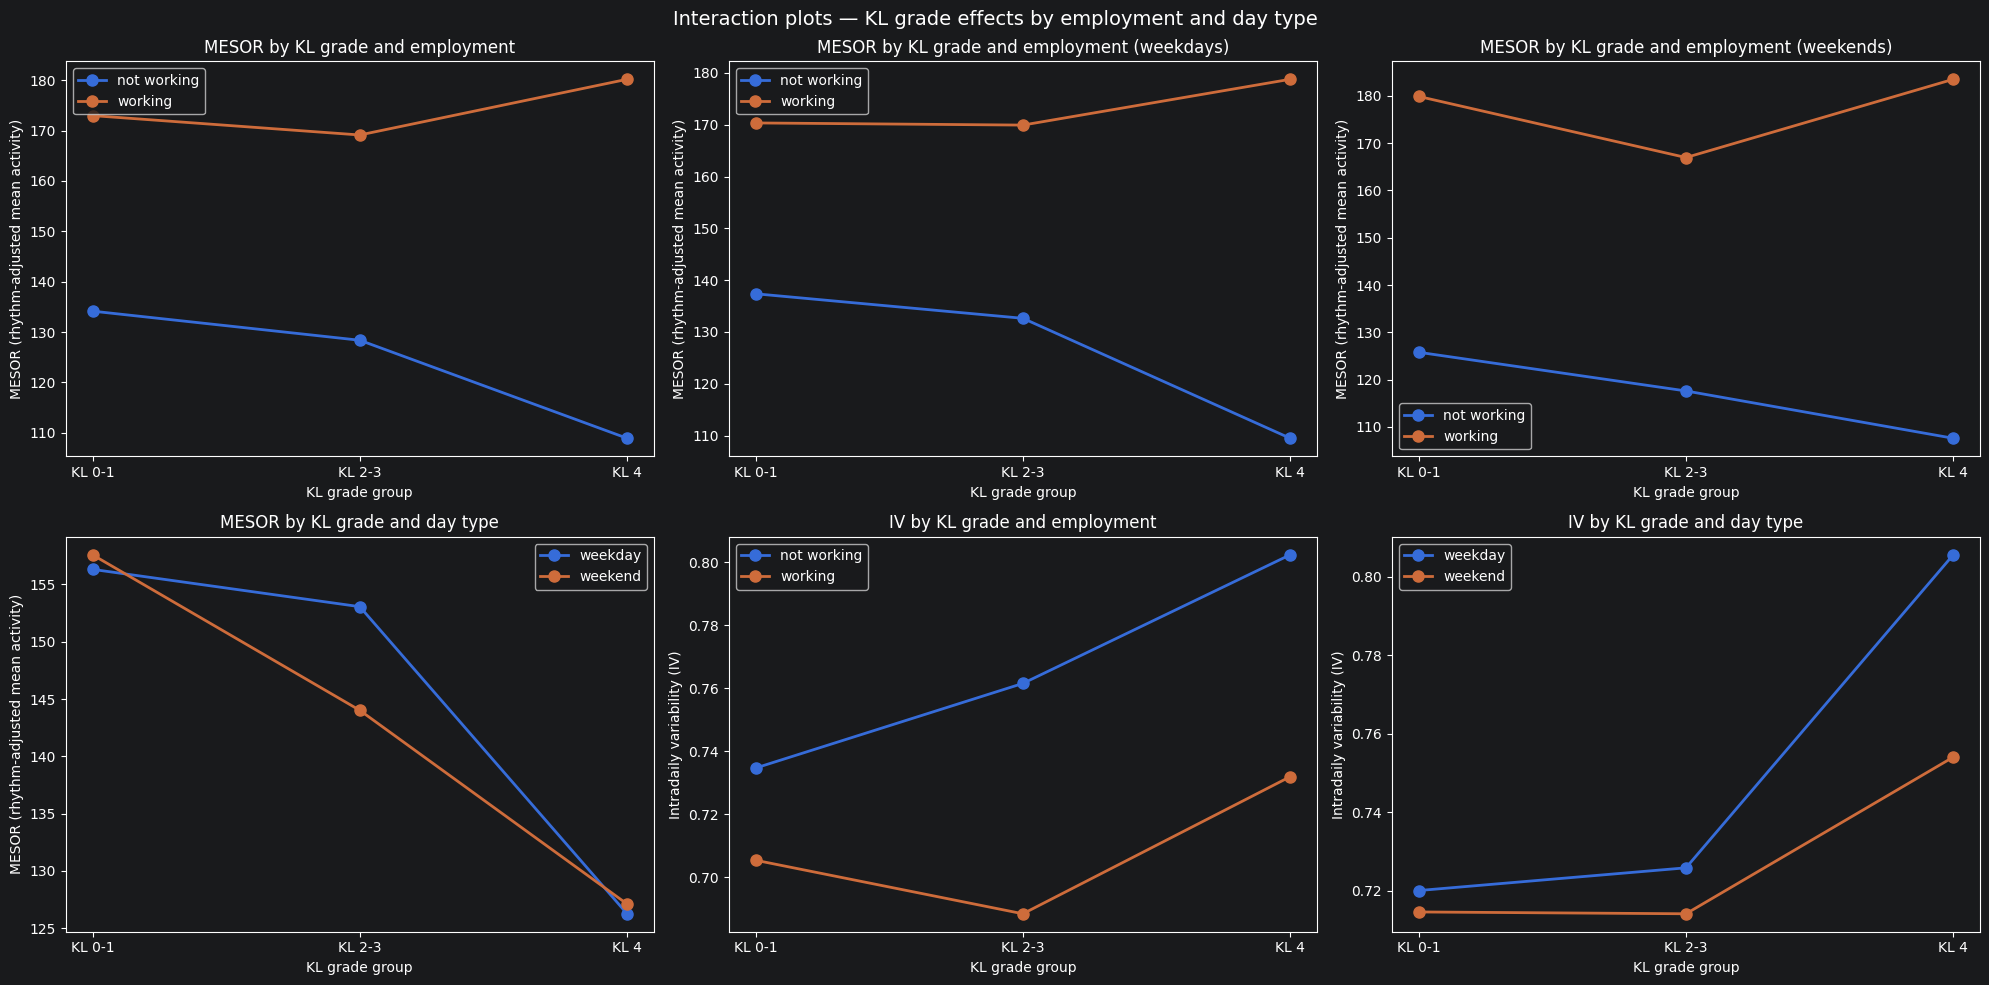

In [94]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

plot_specifications = [
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekdays)",
        "filter": {"column": "day_type", "value": "weekday"},
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekends)",
        "filter": {"column": "day_type", "value": "weekend"},
    },
    {
        "feature": "mesor_daily",
        "group": "day_type",
        "title": "MESOR by KL grade and day type",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "employment_group",
        "title": "IV by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "day_type",
        "title": "IV by KL grade and day type",
        "filter": None,
    },
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    data_subset = (
        daily_metrics_08[
            daily_metrics_08[specification["filter"]["column"]] == specification["filter"]["value"]
        ]
        if specification["filter"] is not None
        else daily_metrics_08
    )

    plot_data = (
        data_subset
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

In [95]:
kl_4_employed_participants = summary_metrics_08[
    (summary_metrics_08["kl_grade"] == 4) &
    (summary_metrics_08["employment_group"] == "working")
][["ID", "employment_group", "kl_grade"]]

print(f"Participants with KL grade 4 and working: {len(kl_4_employed_participants)}")
print(kl_4_employed_participants)

KeyError: 'kl_grade'

# Explore KL4 group

In [ ]:
print(
    summary_metrics_08
    .groupby("kl_grade_group")["mesor"]
    .agg(["mean", "median", "count"])
    .round(2)
)

In [ ]:
print(
    summary_metrics_08
    .groupby(["kl_grade_group", "employment_group"])["mesor"]
    .agg(["mean", "median", "count"])
    .round(2)
)

In [ ]:
print(
    summary_metrics_08
    .groupby(["kl_grade_group", "employment_group"])[["mesor", "V08AGE"]]
    .agg(["mean", "median", "count"])
    .round(2)
)

In [ ]:
kl_4_employed_ids = [9282203, 9332151, 9352020, 9559860, 9693364, 9766889, 9775951, 9833782, 9847829, 9932578]

print(
    summary_metrics_08[summary_metrics_08["ID"].isin(kl_4_employed_ids)]
    .groupby(["ID"])[["mesor", "V08AGE"]]
    .agg(["mean", "median", "count"])
    .round(2)
)